# Step → Ramp → Multi-sine → Newton 전체 응답 피팅 → S-curve 검증



## 0. 준비



In [1]:
# MotorParams를 dataclass로 정의하고, frozen=True 옵션을 사용
# = MotorParams를 만든 뒤 내부 값을 직접 바꾸지 못하게 한다 -> 시뮬레이션 도중 파라미터가 실수로 변경되는 것 방지
from dataclasses import asdict, dataclass, replace
from pathlib import Path
import json
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import warp as wp
from IPython.display import HTML, display
# 전역 탐색, 선형 least squares, 로컬 최적화 
from scipy.optimize import differential_evolution, lsq_linear, minimize

# 프로젝트 루트를 동적으로 찾는다.
# 현재 작업 디렉토리나 그 상위 폴더를 타고 올라가면서 single_motor_twin 파일을 찾는다.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "code" / "single_motor_twin.py").exists()),
    None,
)  
if PROJECT_ROOT is None:
    raise FileNotFoundError("code/single_motor_twin.py를 찾을 수 없습니다.")
if str(PROJECT_ROOT / "code") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "code"))

# 핵심 모델 불러오기 (반복 호출하며 시뮬레이션)
from single_motor_twin import MotorParams, simulate_motor
from wmx_log_utils import load_wmx_log

def resolve_sim_device(prefer_cuda=True):
    if prefer_cuda and wp.get_cuda_devices():
        wp.set_device("cuda")
    else:
        wp.set_device("cpu")
    return str(wp.get_device())

SIM_DEVICE = resolve_sim_device(prefer_cuda=True)
print(f"Newton/Warp device: {SIM_DEVICE}")

MULTI_SINE_CHECKPOINT_PATH = PROJECT_ROOT / "fitted_motor_params_multi_sine_checkpoint.json"
REUSE_MULTI_SINE_CHECKPOINT = True

def checkpoint_log_map(datasets, names):
    return {name: str(datasets[name]["source"]) for name in names}


def save_motor_params_checkpoint(path, stage, params, datasets, fit_names, validation_names, losses=None):
    payload = {
        "stage": stage,
        "motor_params": asdict(params),
        "fit_logs": checkpoint_log_map(datasets, fit_names),
        "validation_logs": checkpoint_log_map(datasets, validation_names),
        "losses": losses,
        "sim_device": SIM_DEVICE,
    }
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return payload


def load_motor_params_checkpoint(path, datasets, fit_names, validation_names):
    payload = json.loads(path.read_text(encoding="utf-8"))
    expected_fit_logs = checkpoint_log_map(datasets, fit_names)
    expected_validation_logs = checkpoint_log_map(datasets, validation_names)
    if payload.get("fit_logs") != expected_fit_logs:
        raise ValueError("checkpoint fit 로그가 현재 설정과 다릅니다. 파일을 지우거나 로그 설정을 확인하세요.")
    if payload.get("validation_logs") != expected_validation_logs:
        raise ValueError("checkpoint validation 로그가 현재 설정과 다릅니다. 파일을 지우거나 로그 설정을 확인하세요.")
    return MotorParams(**payload["motor_params"]), payload

# 최적화가 오래 걸리므로 Jupyter 안에서 진행률을 보여주는 도우미. 오직 시각화용
class ProgressBar:
    def __init__(self, title):
        self.title = title
        self.started_at = time.perf_counter()
        self.last_draw_at = 0.0
        self.handle = display(HTML(""), display_id=True)
        self.update(0, 1, "준비", force=True)

    def update(self, completed, total, detail="", force=False):
        now = time.perf_counter()
        if not force and completed < total and now - self.last_draw_at < 0.15:
            return
        self.last_draw_at = now
        percent = 100.0 * np.clip(completed / max(total, 1), 0.0, 1.0)
        elapsed = now - self.started_at
        self.handle.update(HTML(f"""
        <div style='max-width:760px;font-family:monospace'>
          <div style='display:flex;justify-content:space-between;margin-bottom:4px'>
            <b>{self.title} · {detail}</b><span>{percent:6.2f}%</span>
          </div>
          <div style='height:20px;background:#e5e7eb;border-radius:5px;overflow:hidden'>
            <div style='width:{percent:.2f}%;height:100%;background:#2563eb'></div>
          </div>
          <div style='margin-top:4px'>경과 {elapsed:,.1f}초</div>
        </div>"""))




Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, CUDA driver not available (NVRTC compilation available)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/ireh21/.cache/warp/1.16.0
Newton/Warp device: cpu


Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


## 1. Step, Ramp, Multi-sine, 검증용 S-curve 2개 로그 로드



In [2]:
# 어떤 데이터 로그를 사용할지 정의
# Windows: C:\Users\kate\Downloads\csv_data
# WSL/Jupyter에서는 같은 폴더를 /mnt/c/... 경로로 접근한다.
CSV_DATA_DIR = Path("/mnt/c/Users/kate/Downloads/csv_data")
SINE_FREQUENCIES_HZ = (0.1, 0.2, 0.5, 1, 2)
sine_dataset_names = [f"sine_{frequency:g}hz" for frequency in SINE_FREQUENCIES_HZ]
fit_dataset_names = ["step", "ramp", *sine_dataset_names]
validation_dataset_names = ["scurve_validation_1", "scurve_validation_2"]
# 데이터셋 이름과 실제 CSV 파일을 매핑
LOG_PATHS = {
    # 오른쪽 CSV 파일명만 실제 데이터 파일명으로 각각 수정한다.
    "stop": CSV_DATA_DIR / "stop.csv",
    "step": CSV_DATA_DIR / "step_v.csv",
    "ramp": CSV_DATA_DIR / "ramp_v.csv",
    "sine_0.1hz": CSV_DATA_DIR / "sine_0.1Hz.csv",
    "sine_0.2hz": CSV_DATA_DIR / "sine_0.2Hz.csv",
    "sine_0.5hz": CSV_DATA_DIR / "sine_0.5Hz.csv",
    "sine_1hz": CSV_DATA_DIR / "sine_1Hz.csv",
    "sine_2hz": CSV_DATA_DIR / "sine_2Hz.csv",
    "scurve_validation_1": CSV_DATA_DIR / "SCurve.csv",
    "scurve_validation_2": CSV_DATA_DIR / "SCurve2.csv",
}

missing = [str(path) for path in LOG_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("필요한 로그가 없습니다:\n- " + "\n- ".join(missing))

# 단위 변환 (모델링한 파일의 단위에 맞추기. 해당 단일 모터 모델은 SI 단위를 전제)
DEG_TO_RAD = np.pi / 180.0
RATED_TORQUE_NM = 0.16
PEAK_TORQUE_NM = 3.0 * RATED_TORQUE_NM
FEEDBACK_TORQUE_PERCENT_TO_ACTUAL_NM = RATED_TORQUE_NM / 100.0
LOG_OPTIONS = {
    "cycle_period_s": 1.0e-3,  # 4초 / 4000 cycle = 1 ms/cycle
    "position_scale": DEG_TO_RAD,  # deg -> rad
    "velocity_scale": DEG_TO_RAD,  # deg/s -> rad/s
    # FeedbackTrq-0 [% of rated torque] -> actual torque [N·m]
    # 예: 50% -> 0.08 N·m, 100% -> 0.16 N·m
    "torque_scale": FEEDBACK_TORQUE_PERCENT_TO_ACTUAL_NM,
}
# 토크 제한 관련 상수
# 실측 토크는 현재 로그가 요구한 최소 운전 범위를 확인하는 참고치로만 쓰고,
# 최종 제한은 데이터시트 하한보다 작아지지 않게 둔다.
TORQUE_LIMIT_MARGIN = 1.10
ROTOR_INERTIA_KG_M2 = 0.026e-4  # 브레이크 없음: 0.026 × 10^-4 kg·m²
MAX_EFFECTIVE_INERTIA_KG_M2 = 1.0e-2  # 미상 부하 관성을 포함한 탐색 상한
MIN_VISCOUS_FIT_NM_S_PER_RAD = 1.0e-5
MAX_TORQUE_RESPONSE_TIME_CONSTANT_S = 6.0e-3

# csv 파일을 읽어와서 시뮬레이션에 사용할 수 있는 데이터 구조로 변환
raw_logs = {
    profile: load_wmx_log(path, **LOG_OPTIONS)
    for profile, path in LOG_PATHS.items()
}
for profile, data in raw_logs.items():
    print(f"{profile:18s} N={len(data['time']):5d} dt={data['dt']:.9g}s")


stop               N= 6665 dt=0.001s
step               N=20689 dt=0.001s
ramp               N=29001 dt=0.001s
sine_0.1hz         N=29957 dt=0.001s
sine_0.2hz         N=25093 dt=0.001s
sine_0.5hz         N= 7371 dt=0.001s
sine_1hz           N= 6070 dt=0.001s
sine_2hz           N= 3585 dt=0.001s
scurve_validation_1 N=14295 dt=0.001s
scurve_validation_2 N=20098 dt=0.001s


## 2. 단위, 시간축, 초기상태 정합



torque reference from logs: 0.064592 N·m, applied limits: continuous=0.16 N·m, peak=0.48 N·m
step               origin=+3.63272e-05rad q0=-2.62156e-06rad v0=-1.32012e-14rad/s


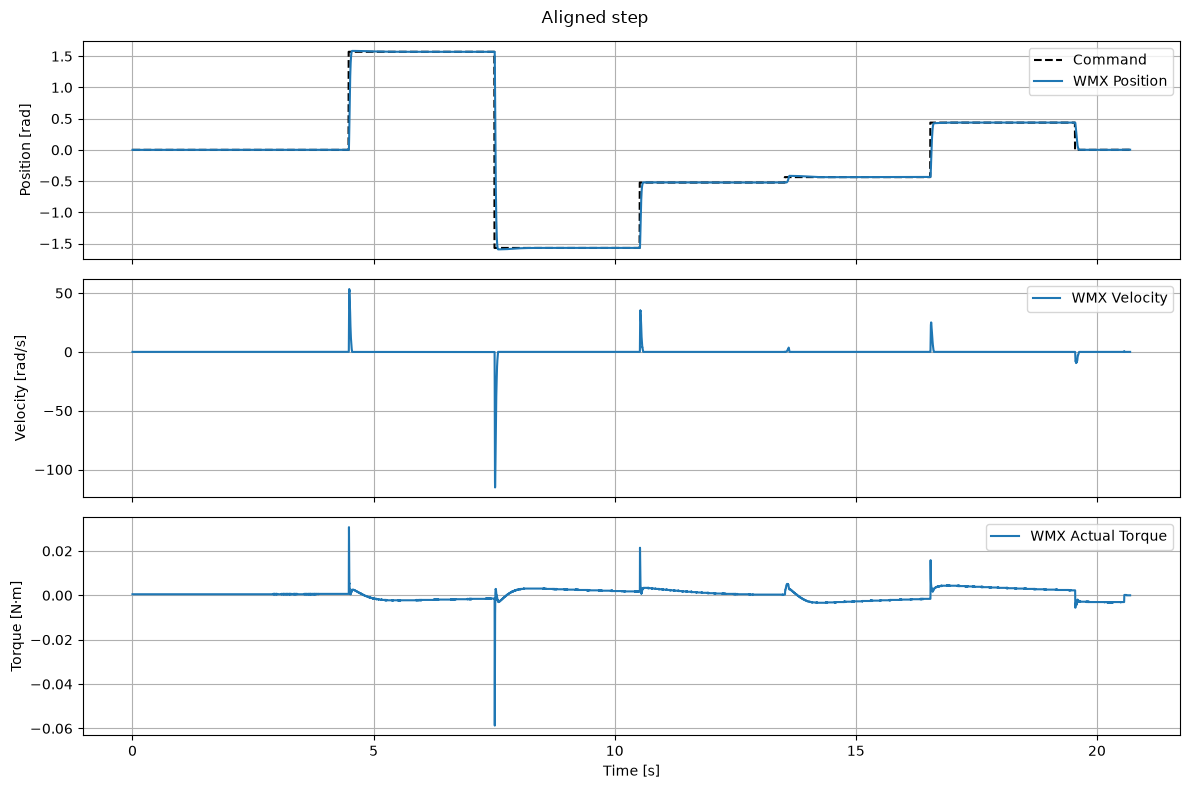

ramp               origin=-6.28397rad q0=-4.15703e-05rad v0=+9.39157e-15rad/s


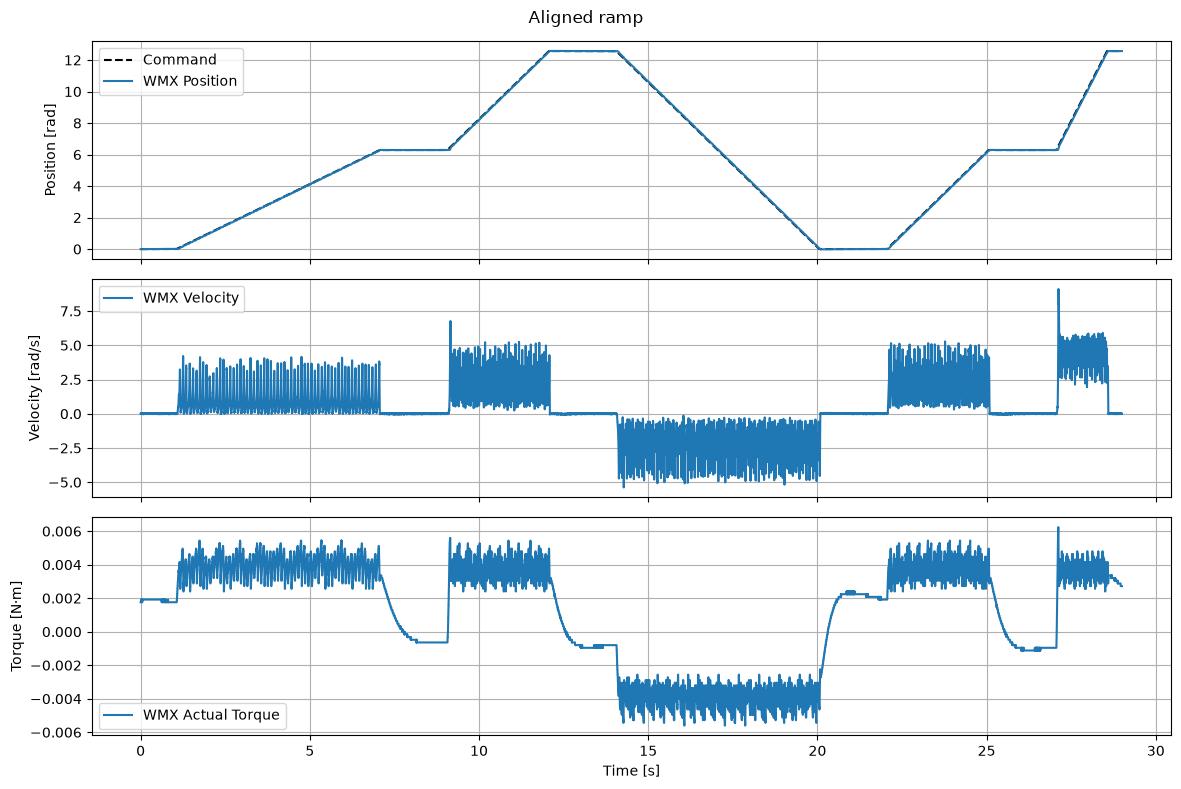

sine_0.1hz         origin=+0.000211971rad q0=-4.60786e-19rad v0=+1.34091e-15rad/s


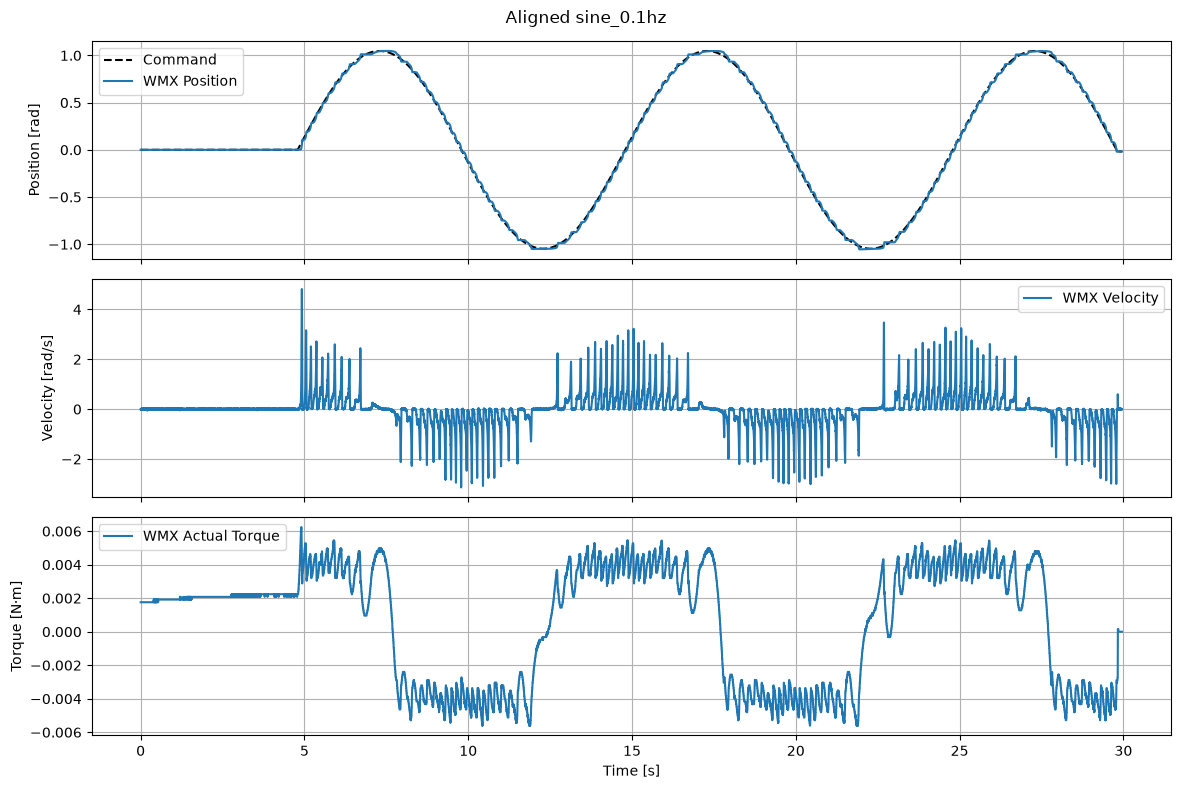

sine_0.2hz         origin=+4.26938e-05rad q0=-7.49026e-07rad v0=+0rad/s


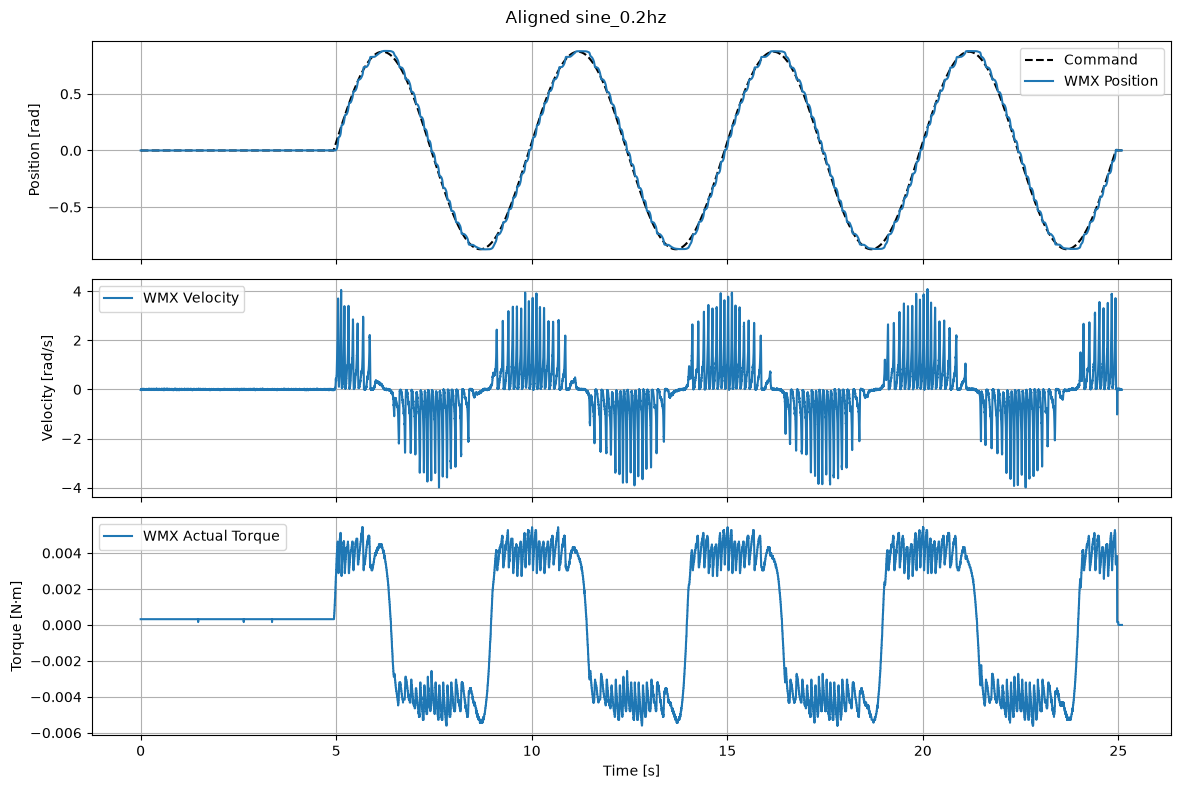

sine_0.5hz         origin=+1.40193rad q0=-0.0290853rad v0=+1.57593rad/s


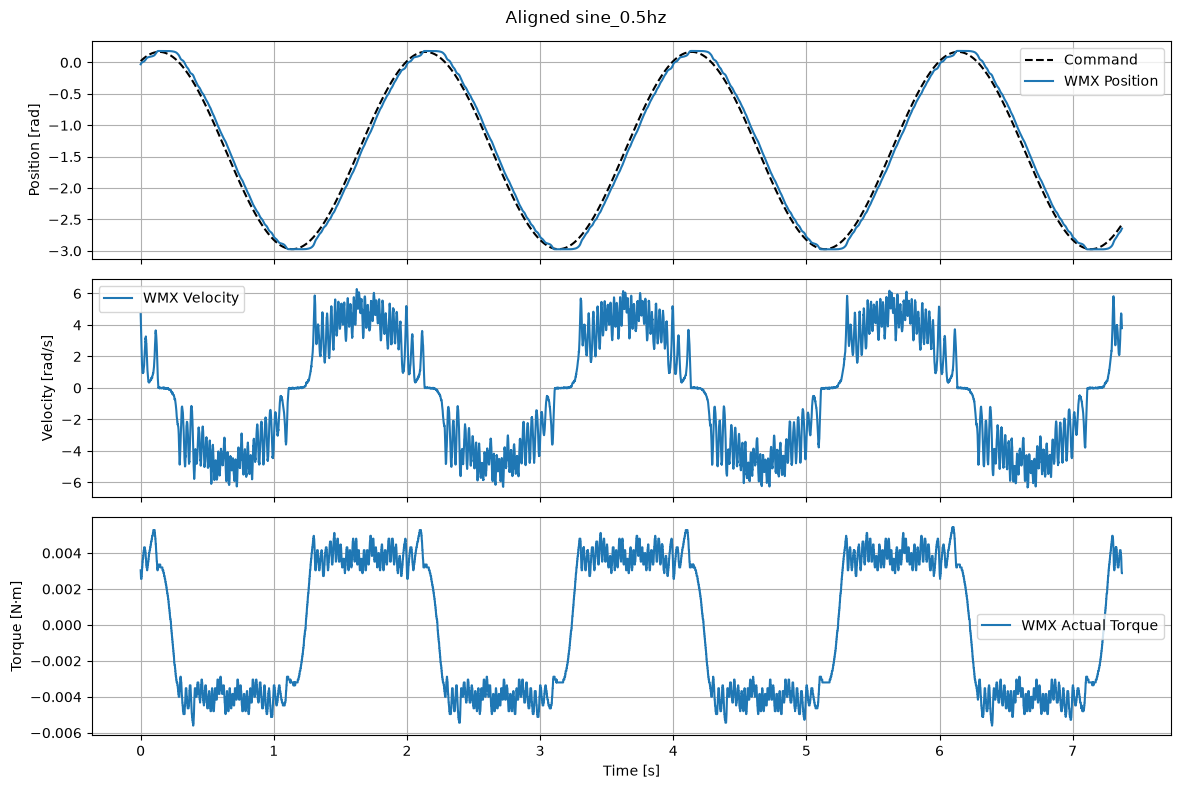

sine_1hz           origin=+0.45065rad q0=-0.0336895rad v0=+3.23574rad/s


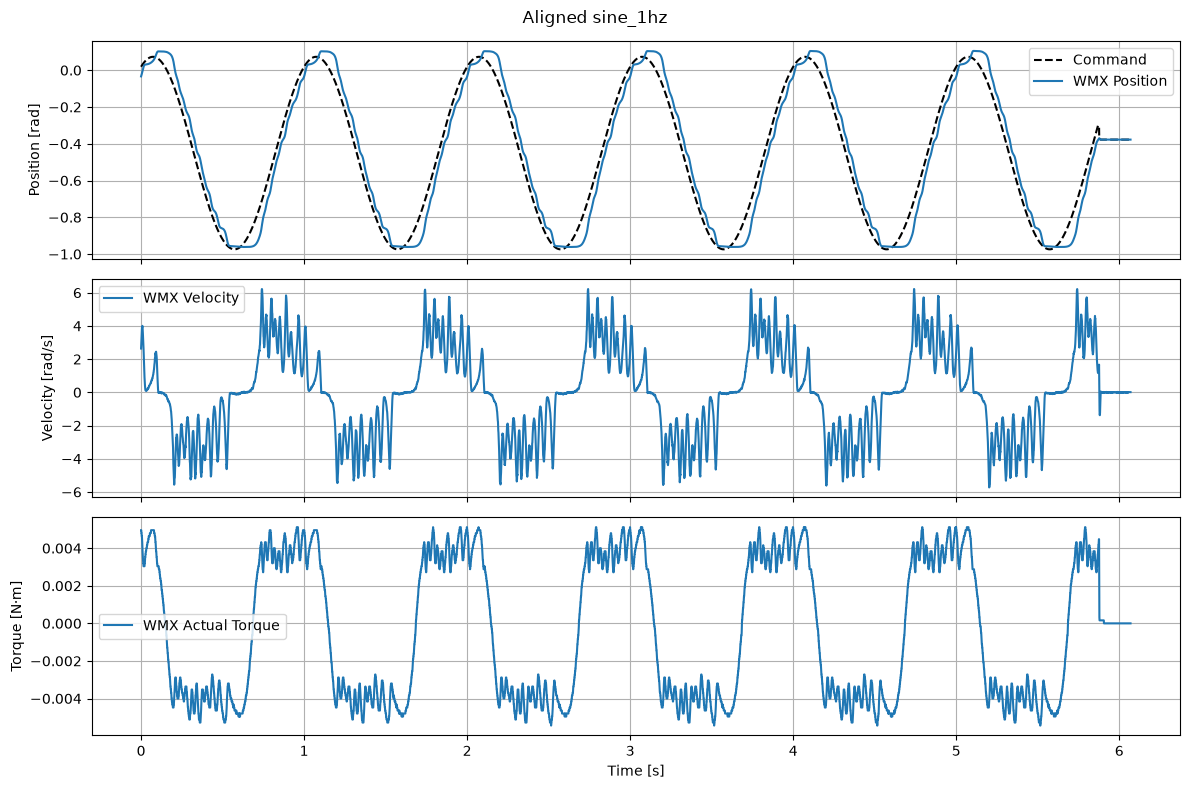

sine_2hz           origin=-0.2754rad q0=+0.00414355rad v0=-0.419448rad/s


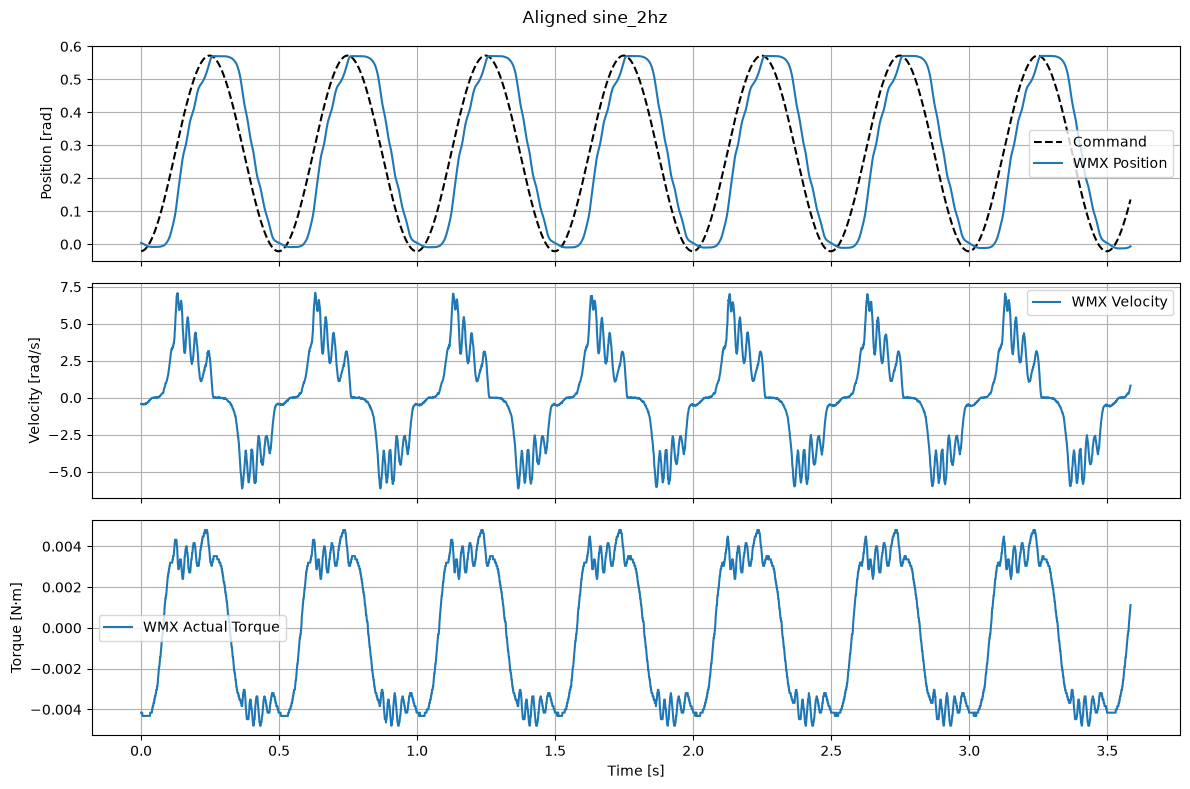

scurve_validation_1 origin=+1.49803e-06rad q0=-4.04468e-05rad v0=+1.98019e-15rad/s


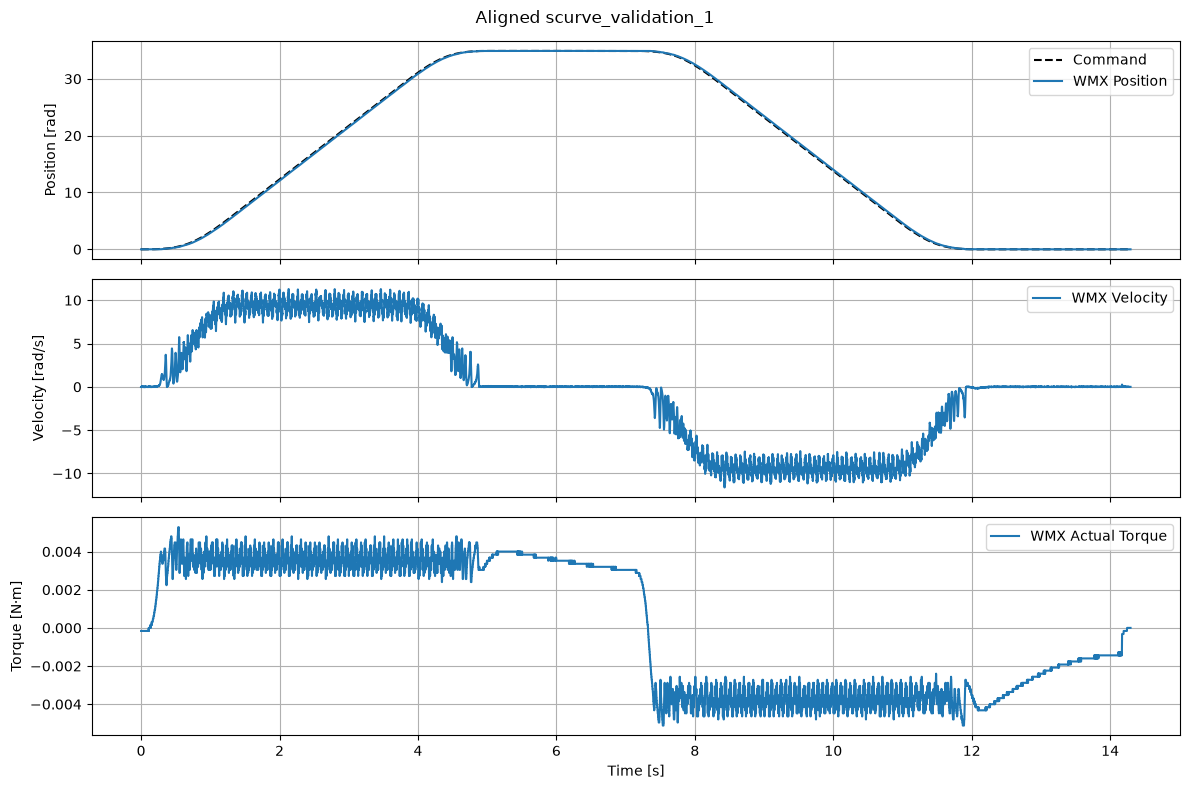

scurve_validation_2 origin=-0.000434803rad q0=+3.37057e-06rad v0=-1.58363e-14rad/s


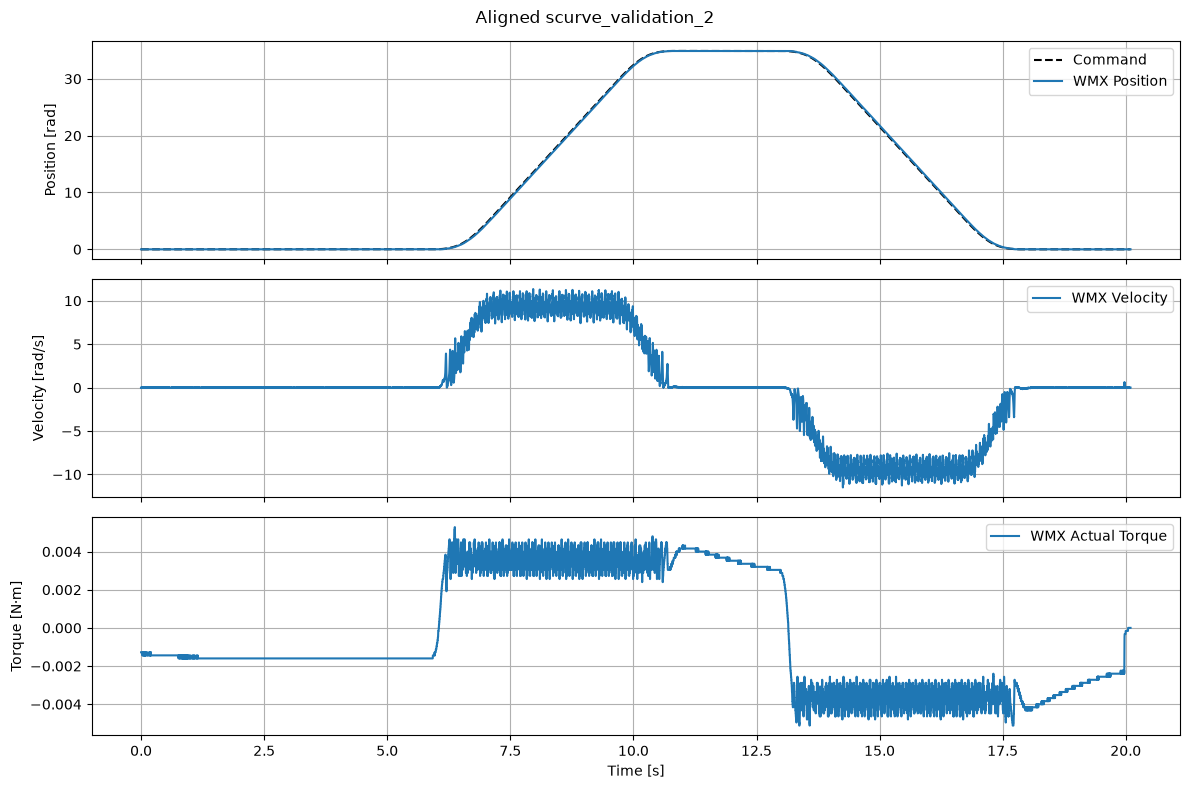

In [3]:
SIGNAL_KEYS = (
    "command_position", "feedback_position", "feedback_velocity", "feedback_torque",
)
INITIAL_WINDOW_S = 0.02

# 시간축 정렬, 초기 위치/속도 정합, 데이터셋 구성, 데이터시트 하한이 있는 토크 제한 산정
def align_log(data, profile):  # 실제 로그 시간 간격 일정하지 않을 수 있음 -> 균일한 시간축 새로 생성
    raw_time = np.asarray(data["time"], dtype=np.float64)
    dt = float(np.median(np.diff(raw_time)))
    count = int(np.floor((raw_time[-1] - raw_time[0]) / dt + 1.0e-9)) + 1
    time_axis = np.arange(count, dtype=np.float64) * dt
    # 보간으로 재샘플링 -> 모든 신호를 균일 시간축으로 맞춤
    result = {
        key: np.interp(time_axis, raw_time - raw_time[0], data[key])
        for key in SIGNAL_KEYS
    }
    initial_count = min(count, max(3, int(round(INITIAL_WINDOW_S / dt))))
    # 초기 위치 원점 제거 (실제 모터와 시뮬레이터가 같은 기준 좌표를 쓰도록 하는 과정)
    position_origin = float(np.median(result["feedback_position"][:initial_count]))
    # 초기 속도 저장 (시뮬레이션 시작 조건을 로그와 맞추는 과정)
    initial_velocity = float(np.median(result["feedback_velocity"][:initial_count]))

    result["command_position"] -= position_origin
    result["feedback_position"] -= position_origin
    result.update({
        "profile": profile,
        "source": data["source"],
        "time": time_axis,
        "dt": dt,
        "source_dt": dt,
        "position_origin": position_origin,
        "initial_position": float(result["feedback_position"][0]),
        "initial_velocity": initial_velocity,
    })
    return result

# 피팅에 사용할 데이터, 검증에 사용할 데이터 분리
datasets = {name: align_log(data, name) for name, data in raw_logs.items()}
fit_datasets = [datasets[name] for name in fit_dataset_names]
validation_datasets = [datasets[name] for name in validation_dataset_names]

# 실측 최대 토크는 현재 로그가 요구한 최소 운전 범위를 알려주는 참고치로만 사용한다.
# 실제 모터의 headroom이 인위적으로 사라지지 않게, 데이터시트 토크 한계를 하한으로 유지한다.
measured_torque_abs_max = max(
    float(np.max(np.abs(data["feedback_torque"])))
    for data in fit_datasets
)
operating_torque_reference_nm = TORQUE_LIMIT_MARGIN * measured_torque_abs_max
DATA_CONTINUOUS_TORQUE_LIMIT_NM = max(RATED_TORQUE_NM, operating_torque_reference_nm)
DATA_PEAK_TORQUE_LIMIT_NM = max(PEAK_TORQUE_NM, operating_torque_reference_nm)
print(
    f"torque reference from logs: {operating_torque_reference_nm:.6g} N·m, "
    f"applied limits: continuous={DATA_CONTINUOUS_TORQUE_LIMIT_NM:.6g} N·m, "
    f"peak={DATA_PEAK_TORQUE_LIMIT_NM:.6g} N·m"
)

# 각 로그를 시각적으로 확인
def plot_log(data, title):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(data["time"], data["command_position"], "k--", label="Command")
    axes[0].plot(data["time"], data["feedback_position"], label="WMX Position")
    axes[1].plot(data["time"], data["feedback_velocity"], label="WMX Velocity")
    axes[2].plot(data["time"], data["feedback_torque"], label="WMX Actual Torque")
    for axis in axes:
        axis.grid(True); axis.legend()
    axes[0].set_ylabel("Position [rad]")
    axes[1].set_ylabel("Velocity [rad/s]")
    axes[2].set_ylabel("Torque [N·m]"); axes[2].set_xlabel("Time [s]")
    fig.suptitle(title); fig.tight_layout(); plt.show()


for name, data in datasets.items():
    if name == "stop":
        continue  # stop 로그는 아래의 전용 셀에서 별도로 분석한다.
    print(
        f"{name:18s} origin={data['position_origin']:+.6g}rad "
        f"q0={data['initial_position']:+.6g}rad "
        f"v0={data['initial_velocity']:+.6g}rad/s"
    )
    plot_log(data, f"Aligned {name}")


### 2.1 Stop 로그 : 토크 바이어스·노이즈 확인

현재 측정 세션의 정지 토크 평균과 노이즈만 확인하며 피팅에는 자동 적용하지 않는다.  
-> 토크의 오차를 얼마나 신뢰할지에 대해 정하는 부분  
-> 정지 상태에서 토크가 흔들리는 건 대부분 측정 노이즈 혹은 미세한 바이어스이다. 그래서 "이 정도 토크 차이는 모델 오차가 아닌 노이즈 일 수 있다"는 기준을 잡는데 사용

Stop torque: mean=0.000602161 N·m, std=6.79889e-05 N·m


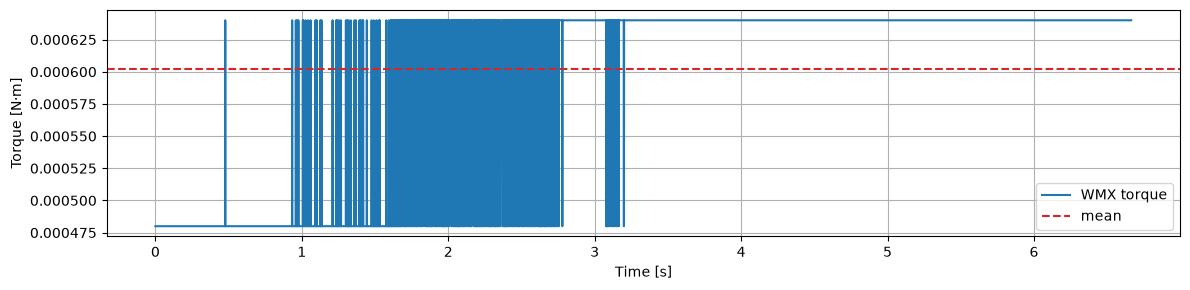

In [4]:
# 정지 후 구간만 사용
STOP_SETTLING_S = 0.5
stop_data = datasets["stop"]
stop_mask = stop_data["time"] >= STOP_SETTLING_S

# 평균과 표준편차
stop_torque = stop_data["feedback_torque"][stop_mask]
stop_torque_mean = np.mean(stop_torque)
stop_torque_std = np.std(stop_torque)
TORQUE_NOISE_FLOOR_NM = 3.0 * stop_torque_std # 3σ. stop 로그로 토크 noise floor를 설정
print(f"Stop torque: mean={stop_torque_mean:.6g} N·m, std={stop_torque_std:.6g} N·m")

# 그래프
plt.figure(figsize=(12, 3))
plt.plot(stop_data["time"], stop_data["feedback_torque"], label="WMX torque")
plt.axhline(stop_torque_mean, color="tab:red", linestyle="--", label="mean")
plt.xlabel("Time [s]"); plt.ylabel("Torque [N·m]")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


## 3. Newton simulation과 Loss



In [5]:
# 어떤 신호를 피팅할 것인가
SIGNALS = {
    "position": "feedback_position",
    "velocity": "feedback_velocity",
    "torque": "feedback_torque",
}
# 동적 토크의 대표 크기로 정규화하되, 정지 로그의 3σ 노이즈보다 작게 잡지 않는다.
TORQUE_FIT_SCALE_NM = max(
    TORQUE_NOISE_FLOOR_NM,
    float(np.median([np.std(data["feedback_torque"]) for data in fit_datasets])),
)
# 정규화된 loss 구성
# 각 신호의 단위가 다르니 서로 다른 스케일로 나눠 MSE를 만든다.
LOSS_SCALES = {"position": 0.05, "velocity": 0.5, "torque": TORQUE_FIT_SCALE_NM}
DEFAULT_WEIGHTS = {"position": 1.0, "velocity": 0.7, "torque": 0.7}

# 데이터 슬라이스
def slice_log(data, start, stop):
    result = {key: np.asarray(data[key])[start:stop] for key in SIGNAL_KEYS}
    result.update({
        "profile": data["profile"],
        "source": data["source"],
        "time": np.arange(stop - start) * data["dt"],
        "dt": data["dt"],
        "source_dt": data["source_dt"],
        "position_origin": data["position_origin"],
        "initial_position": float(result["feedback_position"][0]),
        "initial_velocity": float(result["feedback_velocity"][0]),
    })
    return result

# 시뮬레이션 실행 함수
def run_model(data, params, device=SIM_DEVICE):
    if not np.isclose(data["dt"], data["source_dt"]):
        raise ValueError("시뮬레이션 dt는 원본 로그 dt와 같아야 합니다.")
    return simulate_motor(
        data["command_position"], data["dt"], params,
        device=device, use_viewer=False,
        initial_position=data["initial_position"],
        initial_velocity=data["initial_velocity"],
    )

# 시뮬레이션과 실제 로그를 비교하여 각 신호별 MSE를 계산
# 토크는 stop에서 설정한 noise floor를 적용해, 이보다 작은 토크 오차는 패널티 감소.
def signal_losses(data, simulation, weights=DEFAULT_WEIGHTS):
    losses = {}
    for signal, key in SIGNALS.items():
        error = np.asarray(simulation[key]) - np.asarray(data[key])
        if signal == "torque":
            error = np.sign(error) * np.maximum(np.abs(error) - TORQUE_NOISE_FLOOR_NM, 0.0)
        residual = error / LOSS_SCALES[signal]
        losses[signal] = float(np.mean(residual ** 2))
    losses["total"] = sum(weights[key] * losses[key] for key in SIGNALS) / sum(weights.values())
    return losses

# 시뮬레이션 정상 수행(파라미터 피팅) 되었는지 확인. 
def healthy_simulation(data, simulation, params):
    finite = all(np.all(np.isfinite(simulation[key])) for key in SIGNALS.values())
    command_range = float(np.ptp(data["command_position"]))
    position_range = float(np.ptp(simulation["feedback_position"]))
    moving = command_range < 1.0e-3 or position_range >= max(1.0e-4, 0.01 * command_range)
    physical = (
        params.inertia > 0.0
        and params.peak_torque_limit >= params.continuous_torque_limit
        and params.peak_torque_limit > params.coulomb
        and params.torque_response_time_constant >= 0.0
    )
    return finite and moving and physical

# 시뮬레이션을 반복 실행하며 각 로그별 손실(loss) 계산
def evaluate_params(items, params, weights=DEFAULT_WEIGHTS, progress_title=None, device=SIM_DEVICE):
    rows, simulations = [], []
    progress = ProgressBar(progress_title) if progress_title else None
    for index, data in enumerate(items, 1):
        simulation = run_model(data, params, device=device)
        rows.append(signal_losses(data, simulation, weights))
        simulations.append(simulation)
        if progress:
            progress.update(index, len(items), f"{index}/{len(items)} simulation", force=True)
    means = {
        key: float(np.mean([row[key] for row in rows]))
        for key in (*SIGNALS, "total")
    }
    return {"losses": means, "per_log": rows, "simulations": simulations}

# 시뮬레이션 결과를 출력
def print_evaluation(label, params, evaluation, items):
    print(f"\n{label}\nparams = {asdict(params)}\nmean loss = {evaluation['losses']}")
    for data, loss in zip(items, evaluation["per_log"]):
        print(f"  {data['profile']:18s}: {loss}")


def plot_comparison(data, simulation, title):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(data["time"], data["command_position"], "k--", label="Command")
    for axis, signal, ylabel in zip(
        axes,
        ("feedback_position", "feedback_velocity", "feedback_torque"),
        ("Position [rad]", "Velocity [rad/s]", "Torque [N·m]"),
    ):
        axis.plot(data["time"], data[signal], label="WMX")
        axis.plot(data["time"], simulation[signal], label="Newton")
        axis.set_ylabel(ylabel); axis.grid(True); axis.legend()
    axes[-1].set_xlabel("Time [s]")
    fig.suptitle(title); fig.tight_layout(); plt.show()


# 토크 제한은 데이터시트 하한을 유지하고,
# PID·관성·마찰·토크 응답 지연만 실제 로그에 맞는 규모에서 피팅한다.
current_params = MotorParams(
    kp=0.2, ki=0.0, kd=0.01,
    continuous_torque_limit=DATA_CONTINUOUS_TORQUE_LIMIT_NM,
    peak_torque_limit=DATA_PEAK_TORQUE_LIMIT_NM,
    inertia=1.0e-3, viscous=max(MIN_VISCOUS_FIT_NM_S_PER_RAD, 1.0e-3), coulomb=0.0,
    delay_steps=1,
    torque_response_time_constant=0.0,
)
# Baseline도 원본 1 ms 시간축으로 실행한다.
baseline = evaluate_params(
    fit_datasets, current_params,
    progress_title="Baseline Newton · 원본 1 ms",
)
print_evaluation("Baseline", current_params, baseline, fit_datasets)


Module validate_and_correct_inertia_kernel_5e18b3cd 2f0edb1 load on device 'cpu' took 2.88 ms  (cached)
Module newton._src.geometry.bvh 24ddd6d load on device 'cpu' took 0.43 ms  (cached)
Module newton._src.sim.articulation 57145c7 load on device 'cpu' took 0.51 ms  (cached)
Module newton._src.solvers.featherstone.kernels 4399e75 load on device 'cpu' took 1.27 ms  (cached)

Baseline
params = {'kp': 0.2, 'ki': 0.0, 'kd': 0.01, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 0.001, 'viscous': 0.001, 'coulomb': 0.0, 'delay_steps': 1, 'torque_response_time_constant': 0.0}
mean loss = {'position': 5.7909056576248465, 'velocity': 17.623962124224867, 'torque': 40.435657153478864, 'total': 19.346932980007274}
  step              : {'position': 12.275775485575421, 'velocity': 71.76146829703404, 'torque': 96.48052004693868, 'total': 54.1854863859818}
  ramp              : {'position': 1.391490621133188, 'velocity': 4.2976

## 4. Step: delay 추정



각 Step onset delay: [7] → 중앙값: 7


선택한 delay_steps: 0


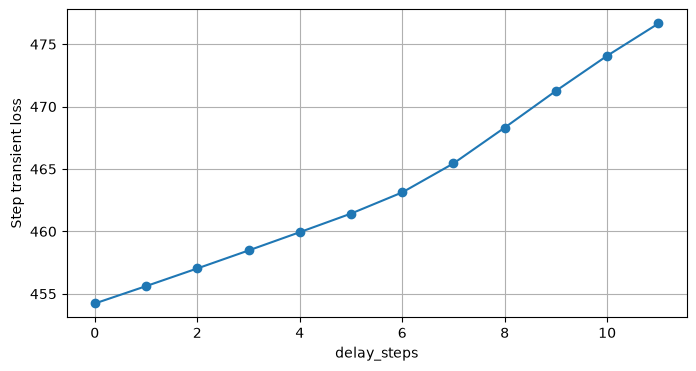

In [6]:
step_data = datasets["step"]
command_jump = np.abs(np.diff(step_data["command_position"], prepend=step_data["command_position"][0]))
jump_threshold = 0.25 * np.max(command_jump)
jump_indices = np.flatnonzero(command_jump >= jump_threshold)
jump_indices = jump_indices[np.r_[True, np.diff(jump_indices) > 10]]

onset_delays = []
for jump in jump_indices:
    before = step_data["feedback_torque"][max(0, jump - 100):jump]
    center = float(np.median(before))
    mad = float(np.median(np.abs(before - center))) + 1.0e-12
    threshold = max(8.0 * 1.4826 * mad, 0.05)
    after = np.abs(step_data["feedback_torque"][jump:jump + 50] - center)
    detected = np.flatnonzero(after > threshold)
    if len(detected):
        onset_delays.append(int(detected[0]))

if not onset_delays:
    raise RuntimeError("Step 토크 응답 onset을 찾지 못했습니다.")
onset_delay = int(round(np.median(onset_delays)))
delay_candidates = range(max(0, onset_delay - 7), onset_delay + 5)
print("각 Step onset delay:", onset_delays, "→ 중앙값:", onset_delay)

step_fit_windows = []
for index, jump in enumerate(jump_indices, 1):
    segment = slice_log(
        step_data,
        max(0, int(jump) - int(round(0.10 / step_data["dt"]))),
        min(len(step_data["time"]), int(jump) + int(round(0.50 / step_data["dt"]))),
    )
    segment["profile"] = f"step_transient_{index}"
    step_fit_windows.append(segment)
step_window = step_fit_windows[0]
STEP_WEIGHTS = {"position": 0.4, "velocity": 0.8, "torque": 1.5}
delay_rows = []
progress = ProgressBar("Step delay sweep")
for index, delay in enumerate(delay_candidates, 1):
    candidate = replace(current_params, delay_steps=int(delay))
    evaluation = evaluate_params([step_window], candidate, STEP_WEIGHTS)
    delay_rows.append({"delay_steps": delay, **evaluation["losses"]})
    progress.update(index, len(delay_candidates), f"delay={delay}", force=True)

selected_delay = min(delay_rows, key=lambda row: row["total"])["delay_steps"]
current_params = replace(current_params, delay_steps=int(selected_delay))
print("선택한 delay_steps:", selected_delay)
plt.figure(figsize=(8, 4))
plt.plot([row["delay_steps"] for row in delay_rows], [row["total"] for row in delay_rows], "o-")
plt.xlabel("delay_steps"); plt.ylabel("Step transient loss"); plt.grid(True); plt.show()

## 5. Ramp: 마찰 초기값 추정



정상속도 samples: 4058 (raw), 7769 (filter=51 samples)
마찰 초기값: {'raw_viscous': 2.925634236912447e-12, 'smoothed_viscous': 1.2731952142155854e-15, 'viscous': 1e-05, 'raw_coulomb': 0.004161931981055078, 'smoothed_coulomb': 0.003974835734783922, 'coulomb': 0.004161931981055078}
Ramp fitting windows: [('ramp', 29000, 0.001000000000000112)]


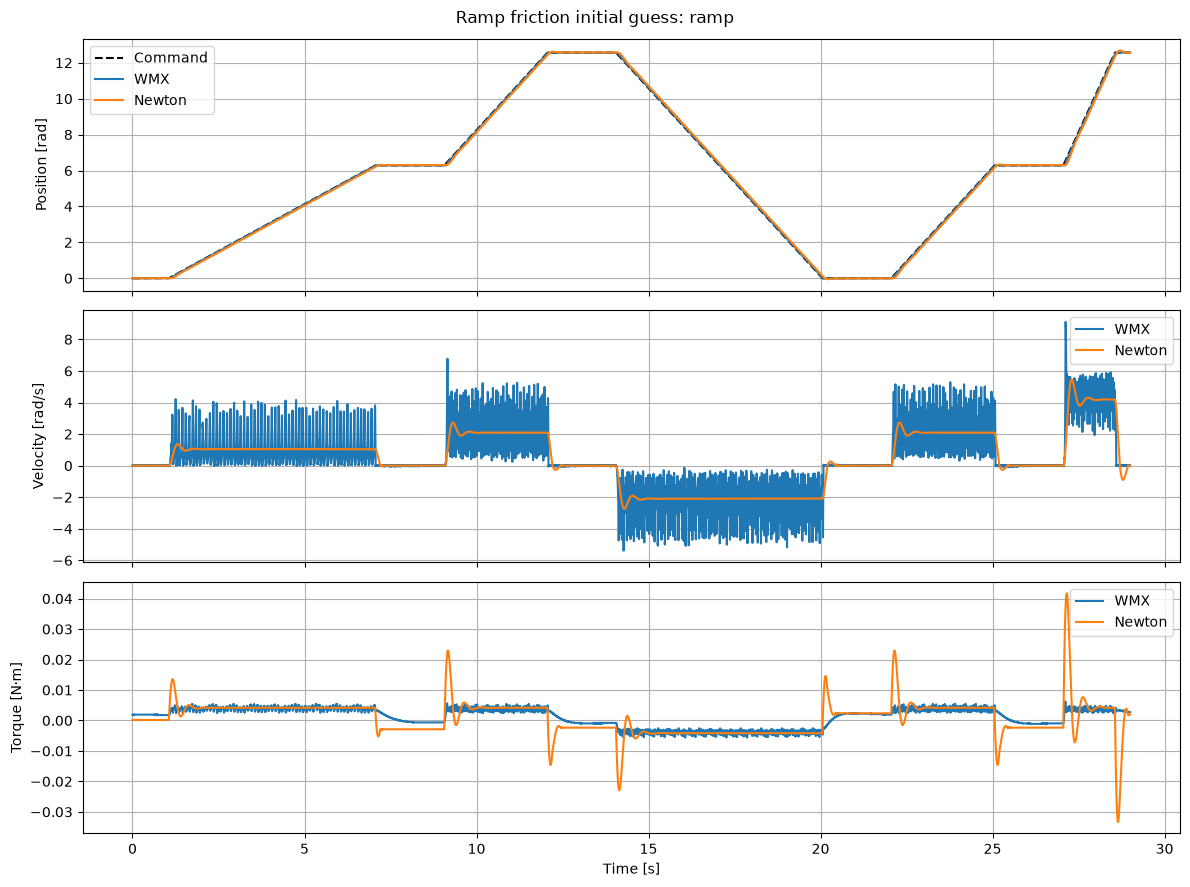

In [7]:
ramp_data = datasets["ramp"]
velocity_raw = np.asarray(ramp_data["feedback_velocity"])
torque_raw = np.asarray(ramp_data["feedback_torque"])
acceleration_raw = np.gradient(velocity_raw, ramp_data["dt"])
# 원시 ramp로 1차 추정을 만든 뒤,
# 50 ms 이동평균 ramp로 보수적인 2차 추정을 더해 viscous가 0으로 붕괴하지 않게 한다.
raw_moving_threshold = max(0.02, 0.15 * np.quantile(np.abs(velocity_raw), 0.95))
raw_acceleration_limit = np.quantile(np.abs(acceleration_raw), 0.60)
steady_raw = (
    (np.abs(velocity_raw) >= raw_moving_threshold)
    & (np.abs(acceleration_raw) <= raw_acceleration_limit)
)
X_raw = np.column_stack((velocity_raw[steady_raw], np.sign(velocity_raw[steady_raw])))
y_raw = torque_raw[steady_raw]

filter_count = max(3, int(round(0.05 / ramp_data["dt"])))
if filter_count % 2 == 0:
    filter_count += 1
filter_kernel = np.ones(filter_count, dtype=np.float64) / filter_count
velocity = np.convolve(velocity_raw, filter_kernel, mode="same")
torque = np.convolve(torque_raw, filter_kernel, mode="same")
acceleration = np.gradient(velocity, ramp_data["dt"])
moving_threshold = max(0.02, 0.15 * np.quantile(np.abs(velocity), 0.95))
acceleration_limit = np.quantile(np.abs(acceleration), 0.60)
steady = (np.abs(velocity) >= moving_threshold) & (np.abs(acceleration) <= acceleration_limit)
X = np.column_stack((velocity[steady], np.sign(velocity[steady])))
y = torque[steady]

if len(y_raw) < 20 or np.linalg.matrix_rank(X_raw) < 2:
    raise RuntimeError("Ramp 로그에 양/음 방향 정상속도 구간이 충분하지 않습니다. (raw)")
if len(y) < 20 or np.linalg.matrix_rank(X) < 2:
    raise RuntimeError("Ramp 로그에 양/음 방향 정상속도 구간이 충분하지 않습니다. (smoothed)")
raw_friction_result = lsq_linear(X_raw, y_raw, bounds=(0.0, np.inf))
friction_result = lsq_linear(X, y, bounds=(0.0, np.inf))
raw_viscous0, raw_coulomb0 = map(float, raw_friction_result.x)
smoothed_viscous0, smoothed_coulomb0 = map(float, friction_result.x)
viscous0 = max(MIN_VISCOUS_FIT_NM_S_PER_RAD, raw_viscous0, smoothed_viscous0)
coulomb0 = max(raw_coulomb0, smoothed_coulomb0)
current_params = replace(current_params, viscous=viscous0, coulomb=coulomb0)
print("정상속도 samples:", int(np.sum(steady_raw)), f"(raw), {int(np.sum(steady))} (filter={filter_count} samples)")
print(
    "마찰 초기값:",
    {
        "raw_viscous": raw_viscous0,
        "smoothed_viscous": smoothed_viscous0,
        "viscous": viscous0,
        "raw_coulomb": raw_coulomb0,
        "smoothed_coulomb": smoothed_coulomb0,
        "coulomb": coulomb0,
    },
)

# 마찰 초기값은 정상속도 구간에서 추정하되,
# 실제 refinement에는 ramp 전체 로그를 사용해 정지/반전 구간도 학습시킨다.
ramp_fit_windows = [ramp_data]
print("Ramp fitting windows:", [(d["profile"], len(d["time"]), d["dt"]) for d in ramp_fit_windows])

ramp_initial = evaluate_params(
      ramp_fit_windows, current_params,
      weights={"position": 0.3, "velocity": 0.9, "torque": 0.9},
      progress_title="Ramp 마찰 초기값 확인 · 원본 1 ms",
)
for data, simulation in zip(ramp_fit_windows, ramp_initial["simulations"]):
    plot_comparison(data, simulation, f"Ramp friction initial guess: {data['profile']}")


## 6. Multi-sine: 관성, 제어 게인 초기값 추정



In [8]:
LOG_PARAMETERS = {"kp", "inertia"}


@dataclass
class FitResult:
    params: MotorParams
    before: dict
    after: dict
    evaluations: int


def decode_parameters(z, names, bounds, base_params):
    updates = {}
    for normalized, name in zip(z, names):
        lower, upper = bounds[name]
        if name in LOG_PARAMETERS and lower > 0.0:
            updates[name] = float(np.exp(np.log(lower) + normalized * np.log(upper / lower)))
        else:
            updates[name] = float(lower + normalized * (upper - lower))
    return replace(base_params, **updates)


# delay는 step sweep으로 따로 고정하고, 연속 파라미터만 현재 값 주변에서 미세조정한다.
REFINEMENT_LIMITS = {
    "kp": {"hard": (0.02, 4.0), "scale": (0.5, 1.5), "min_width": 0.10},
    "kd": {"hard": (5.0e-4, 0.25), "scale": (0.5, 1.5), "min_width": 2.0e-3},
    "inertia": {"hard": (ROTOR_INERTIA_KG_M2, 1.0e-3), "scale": (0.5, 1.5), "min_width": 5.0e-5},
    "viscous": {"hard": (MIN_VISCOUS_FIT_NM_S_PER_RAD, 5.0e-3), "scale": (0.5, 2.0), "min_width": 2.0e-4},
    "coulomb": {"hard": (0.0, 5.0e-2), "scale": (0.5, 1.5), "min_width": 1.0e-3},
    "torque_response_time_constant": {"hard": (0.0, 8.0e-3), "scale": (0.5, 1.5), "min_width": 2.0e-3},
}


def bounds_around(params):
    bounds = {}
    for name, spec in REFINEMENT_LIMITS.items():
        value = float(getattr(params, name))
        hard_min, hard_max = map(float, spec["hard"])
        if name == "coulomb":
            hard_max = min(hard_max, float(params.peak_torque_limit) * 0.95)
        lower_scale, upper_scale = spec["scale"]
        lower = value * lower_scale
        upper = value * upper_scale
        width = max(upper - lower, float(spec["min_width"]))
        if value <= hard_min:
            lower = hard_min
            upper = hard_min + width
        else:
            lower = value - 0.5 * width
            upper = value + 0.5 * width
        lower = float(max(hard_min, lower))
        upper = float(min(hard_max, upper))
        if upper <= lower:
            lower = hard_min
            upper = hard_max
        bounds[name] = (lower, upper)
    return bounds


def make_objective(items, base_params, bounds, weights, progress, total_evaluations):
    names = tuple(bounds)
    counter = {"value": 0}

    def objective(z):
        counter["value"] += 1
        try:
            params = decode_parameters(z, names, bounds, base_params)
            if params.peak_torque_limit <= params.coulomb:
                loss = 1.0e12
            else:
                evaluation = evaluate_params(items, params, weights)
                healthy = all(
                    healthy_simulation(data, simulation, params)
                    for data, simulation in zip(items, evaluation["simulations"])
                )
                loss = evaluation["losses"]["total"] if healthy else 1.0e12
        except (FloatingPointError, OverflowError, ValueError, RuntimeError):
            loss = 1.0e12
        displayed = min(counter["value"], max(total_evaluations - 1, 0))
        progress.update(
            displayed, total_evaluations,
            f"평가 {counter['value']} · 기준 예산 {total_evaluations} · loss={loss:.6g}",
        )
        return loss

    return objective, counter


def fit_global_local(items, base_params, bounds, weights, title,
                     de_maxiter=6, de_popsize=4, local_maxfun=60, seed=42):
    names = tuple(bounds)
    unit_bounds = [(0.0, 1.0)] * len(names)
    before = evaluate_params(items, base_params, weights)
    global_budget = (de_maxiter + 1) * de_popsize * len(names)
    total_budget = global_budget + local_maxfun
    progress = ProgressBar(title)
    objective, counter = make_objective(
        items, base_params, bounds, weights, progress, total_budget,
    )
    global_result = differential_evolution(
        objective, unit_bounds, seed=seed, maxiter=de_maxiter, popsize=de_popsize,
        polish=False, workers=1, updating="immediate",
    )
    local_result = minimize(
        objective, global_result.x, method="L-BFGS-B", bounds=unit_bounds,
        options={"maxiter": local_maxfun, "maxfun": local_maxfun, "eps": 2.0e-3},
    )
    best_z = local_result.x if local_result.fun < global_result.fun else global_result.x
    candidate = decode_parameters(best_z, names, bounds, base_params)
    progress.update(total_budget - 1, total_budget, "최적 후보 재검증", force=True)
    after = evaluate_params(items, candidate, weights)
    if after["losses"]["total"] >= before["losses"]["total"]:
        warnings.warn("후보가 시작값보다 좋지 않아 시작값을 유지합니다.")
        candidate, after = base_params, before
    progress.update(total_budget, total_budget, f"완료 · loss={after['losses']['total']:.6g}", force=True)
    return FitResult(candidate, before, after, counter["value"])


def sweep_delay_steps(items, base_params, delay_candidates, weights, title):
    delay_rows = []
    progress = ProgressBar(title)
    best_delay = int(base_params.delay_steps)
    best_evaluation = None
    for index, delay in enumerate(delay_candidates, 1):
        candidate = replace(base_params, delay_steps=int(delay))
        evaluation = evaluate_params(items, candidate, weights)
        row = {"delay_steps": int(delay), **evaluation["losses"]}
        delay_rows.append(row)
        if best_evaluation is None or row["total"] < best_evaluation["losses"]["total"]:
            best_delay = int(delay)
            best_evaluation = evaluation
        progress.update(
            index, len(delay_candidates),
            f"delay={delay} · loss={row['total']:.6g}",
            force=True,
        )
    selected_params = replace(base_params, delay_steps=int(best_delay))
    return selected_params, delay_rows, best_evaluation


def encode_parameters(params, names, bounds):
    values = asdict(params)
    encoded = []
    for name in names:
        lower, upper = bounds[name]
        value = float(np.clip(values[name], lower, upper))
        if name in LOG_PARAMETERS and lower > 0.0:
            encoded.append(np.log(value / lower) / np.log(upper / lower))
        else:
            encoded.append((value - lower) / (upper - lower))
    return np.asarray(encoded, dtype=np.float64)

def fit_local_refinement(items, base_params, bounds, weights, title,
                         budget=140, maxiter=35):
    names = tuple(bounds)
    progress = ProgressBar(title)
    objective, counter = make_objective(
        items, base_params, bounds, weights, progress, budget,
    )
    z0 = encode_parameters(base_params, names, bounds)
    result = minimize(
        objective, z0, method="L-BFGS-B",
        bounds=[(0.0, 1.0)] * len(names),
        options={"maxiter": maxiter, "maxfun": budget, "eps": 2.0e-3},
    )
    candidate = decode_parameters(
        result.x, names, bounds, base_params,
    )
    progress.update(budget - 1, budget, "최적 후보 재검증", force=True)
    before = evaluate_params(items, base_params, weights)
    after = evaluate_params(items, candidate, weights)
    if after["losses"]["total"] >= before["losses"]["total"]:
        warnings.warn("전체 미세조정 결과가 개선되지 않아 현재 값을 유지합니다.")
        candidate, after = base_params, before
    progress.update(budget, budget, f"완료 · loss={after['losses']['total']:.6g}", force=True)
    return FitResult(candidate, before, after, counter["value"])


def sine_fit_window(data, frequency_hz, settling_cycles=1.0, min_fit_cycles=2.0):
    start = int(round(settling_cycles / frequency_hz / data["dt"]))
    min_count = int(round(min_fit_cycles / frequency_hz / data["dt"]))
    stop = len(data["time"])
    if stop - start < max(20, int(0.8 * min_count)):
        start = max(0, stop - min_count)
    segment = slice_log(data, start, stop)
    used_cycles = max(0.0, (stop - start) * data["dt"] * frequency_hz)
    segment["profile"] = (
        f"{data['profile']}_steady_after_{settling_cycles:g}cycle_"
        f"used_{used_cycles:.2f}cycles"
    )
    return segment


# 초기 과도 1주기를 버린 뒤 남은 정상상태 구간을 최대한 사용하되 원본 1 ms dt를 유지한다.
# 다만 로그 길이가 짧으면 마지막 최소 2주기는 확보하고,
# 토크 응답 지연도 함께 식별해 sine에서 보이는 위상차를 kd만으로 억지 보상하지 않게 한다.
multi_sine_windows = [
    sine_fit_window(datasets[name], frequency)
    for name, frequency in zip(sine_dataset_names, SINE_FREQUENCIES_HZ)
]
print("Multi-sine fitting windows:", [(d["profile"], len(d["time"]), d["dt"]) for d in multi_sine_windows])
MULTI_SINE_BOUNDS = {
    "inertia": (ROTOR_INERTIA_KG_M2, 1.0e-3),
    "kp": (0.02, 4.0),
    "kd": (5.0e-4, 0.25),
    "torque_response_time_constant": (0.0, 8.0e-3),
}
MULTI_SINE_WEIGHTS = {"position": 1.0, "velocity": 1.0, "torque": 0.6}
if REUSE_MULTI_SINE_CHECKPOINT and MULTI_SINE_CHECKPOINT_PATH.exists():
    current_params, multi_sine_checkpoint = load_motor_params_checkpoint(
        MULTI_SINE_CHECKPOINT_PATH,
        datasets,
        fit_dataset_names,
        validation_dataset_names,
    )
    print("Multi-sine checkpoint 불러옴:", MULTI_SINE_CHECKPOINT_PATH.resolve())
    print("checkpoint params:", asdict(current_params))
    print("checkpoint losses:", multi_sine_checkpoint.get("losses"))
else:
    multi_sine_fit = fit_global_local(
        multi_sine_windows, current_params, MULTI_SINE_BOUNDS, MULTI_SINE_WEIGHTS,
        "Multi-sine inertia/kp/kd/torque_tau 초기값",
    )
    current_params = multi_sine_fit.params
    print_evaluation(
        "Multi-sine 초기 피팅", current_params, multi_sine_fit.after, multi_sine_windows,
    )
    for data, simulation in zip(multi_sine_windows, multi_sine_fit.after["simulations"]):
        plot_comparison(data, simulation, f"Multi-sine initial fit: {data['profile']}")
    save_motor_params_checkpoint(
        MULTI_SINE_CHECKPOINT_PATH,
        "after_multi_sine",
        current_params,
        datasets,
        fit_dataset_names,
        validation_dataset_names,
        losses=multi_sine_fit.after["losses"],
    )
    print("Multi-sine checkpoint 저장 완료:", MULTI_SINE_CHECKPOINT_PATH.resolve())


Multi-sine fitting windows: [('sine_0.1hz_steady_after_1cycle_used_2.00cycles', 19956, 0.001000000000000112), ('sine_0.2hz_steady_after_1cycle_used_4.02cycles', 20093, 0.0010000000000000009), ('sine_0.5hz_steady_after_1cycle_used_2.69cycles', 5371, 0.0010000000000000009), ('sine_1hz_steady_after_1cycle_used_5.07cycles', 5070, 0.0010000000000000009), ('sine_2hz_steady_after_1cycle_used_6.17cycles', 3085, 0.0010000000000000009)]
Multi-sine checkpoint 불러옴: /home/ireh21/rei/fitted_motor_params_multi_sine_checkpoint.json
checkpoint params: {'kp': 1.4290473146025706, 'ki': 0.0, 'kd': 0.0427577963253064, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 2.1078659069742927e-05, 'viscous': 1e-05, 'coulomb': 0.004161931981055078, 'delay_steps': 0, 'torque_response_time_constant': 0.0021890134334808455}
checkpoint losses: {'position': 0.3441929239195097, 'velocity': 3.8592585933993755, 'torque': 0.42779715516757966, 'total':

## 7. Step + Ramp + Multi-sine 전체 Newton 응답 미세조정



delay 재확인: {'before': 0, 'after': 6, 'step_loss': 53.16127112394584, 'changed': True}



최종 fitting
params = {'kp': 1.7834420458981466, 'ki': 0.0, 'kd': 0.03489275095941144, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 8.092287352071479e-06, 'viscous': 0.00016529462201840913, 'coulomb': 0.0039704990270451514, 'delay_steps': 6, 'torque_response_time_constant': 0.0024624683815092636}
mean loss = {'position': 0.24199713976088288, 'velocity': 4.627082601076721, 'torque': 1.2880112866322064, 'total': 1.9131047115107784}
  step              : {'position': 0.086678381208176, 'velocity': 9.269929452610809, 'torque': 6.326665053965313, 'total': 4.832289994795797}
  ramp              : {'position': 0.06198988687715753, 'velocity': 3.9661846907162523, 'torque': 0.4648866654652304, 'total': 1.3872488353162862}
  sine_0.1hz        : {'position': 0.08157826582956289, 'velocity': 1.0972978197572325, 'torque': 0.21882546849174758, 'total': 0.4363372678572104}
  sine_0.2hz        : {'position': 0.088020337502730

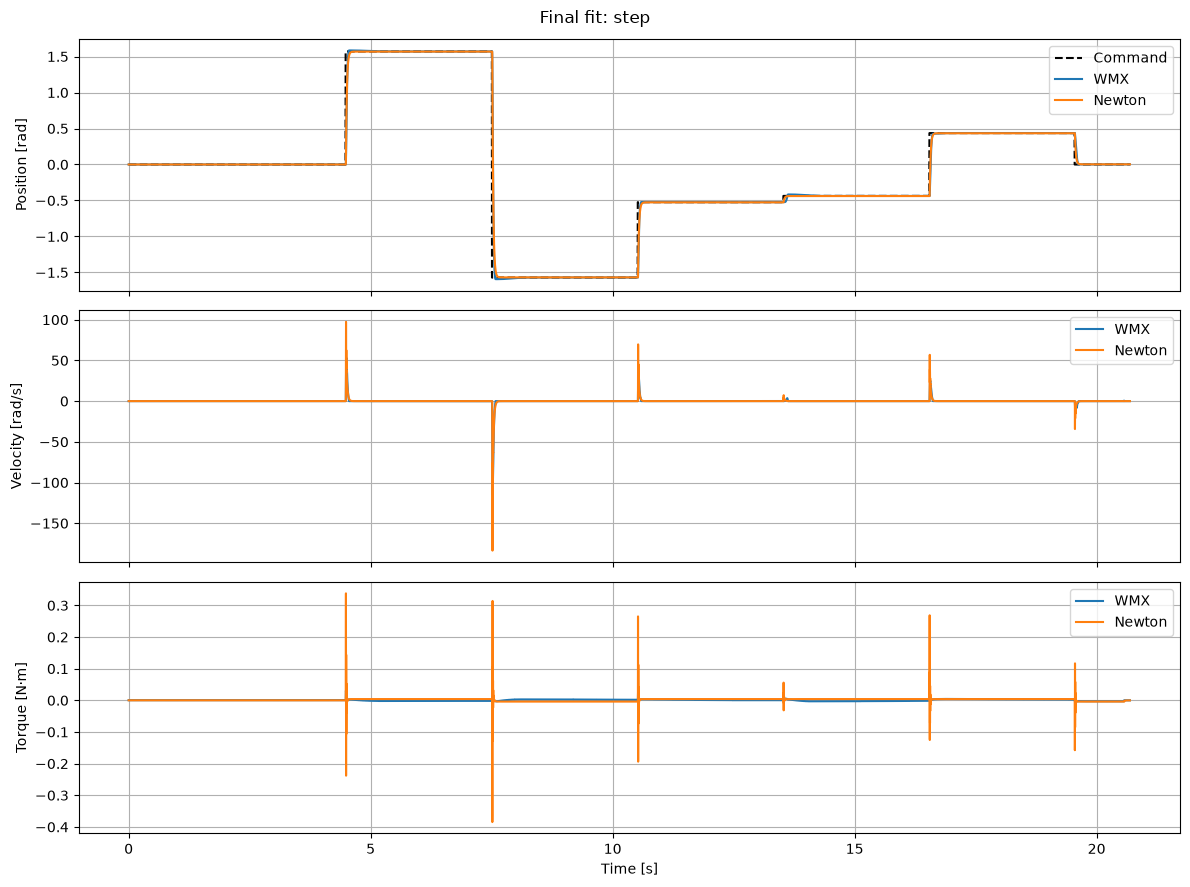

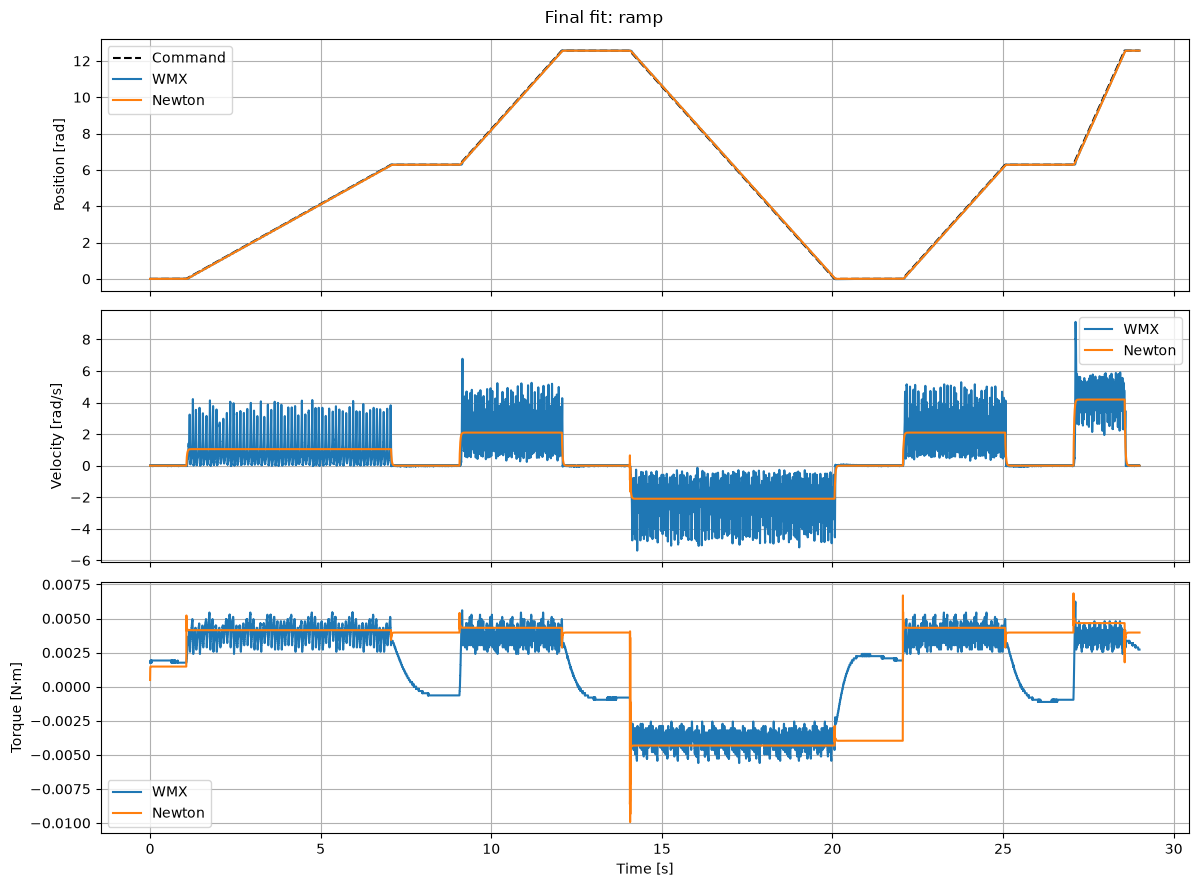

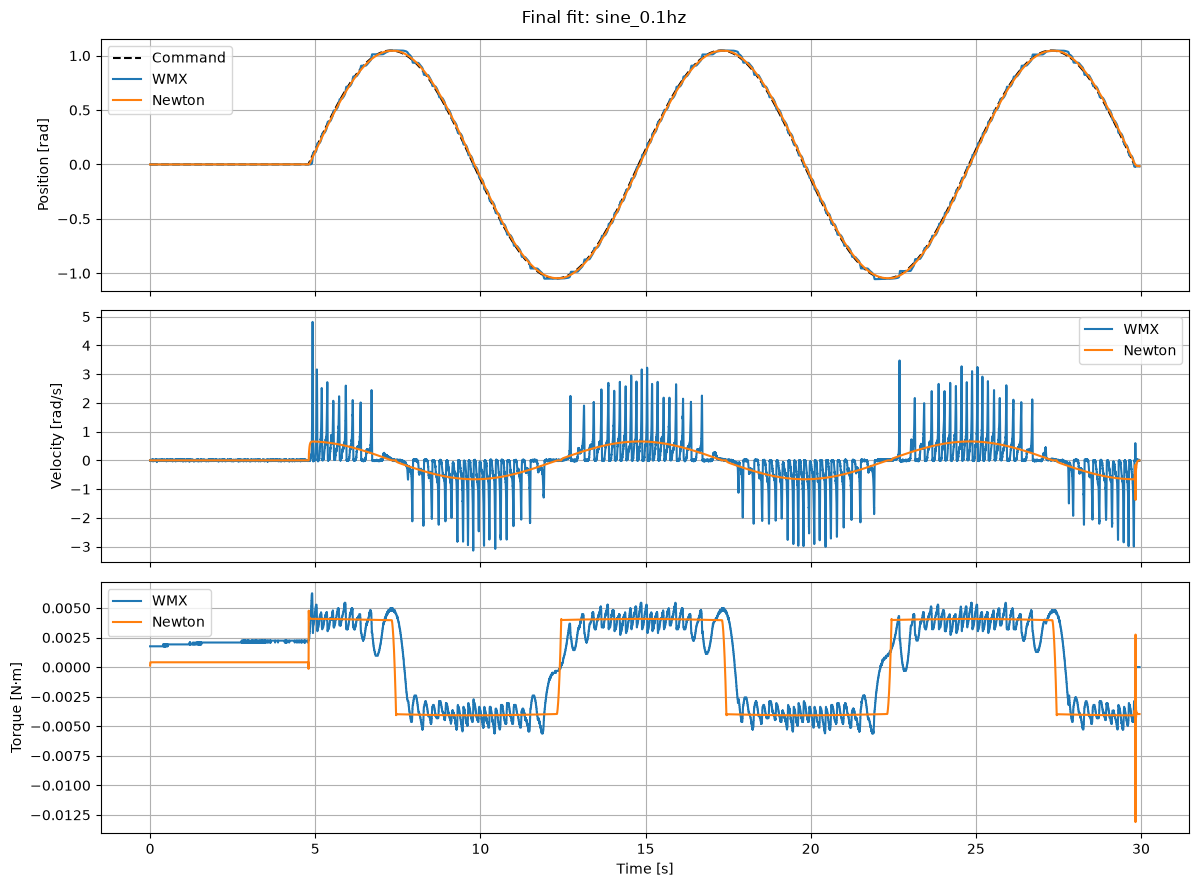

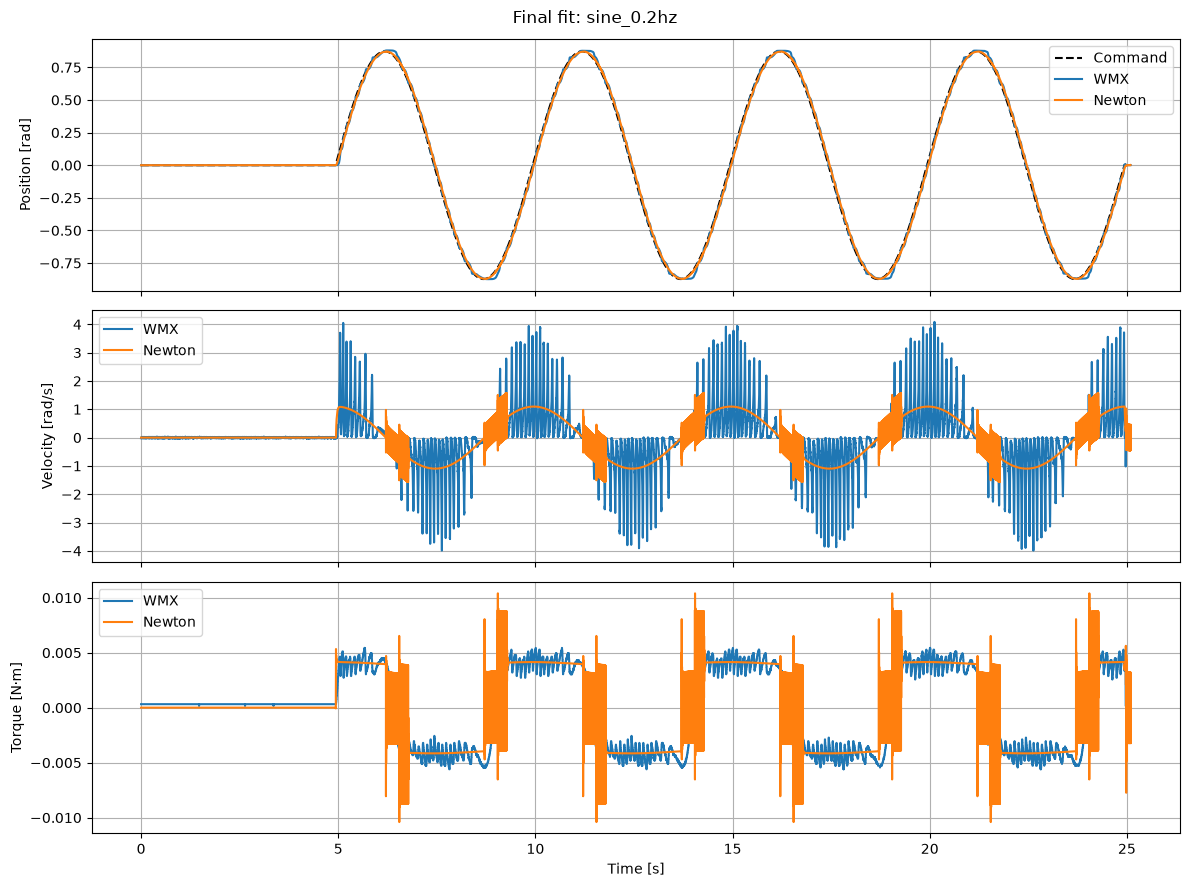

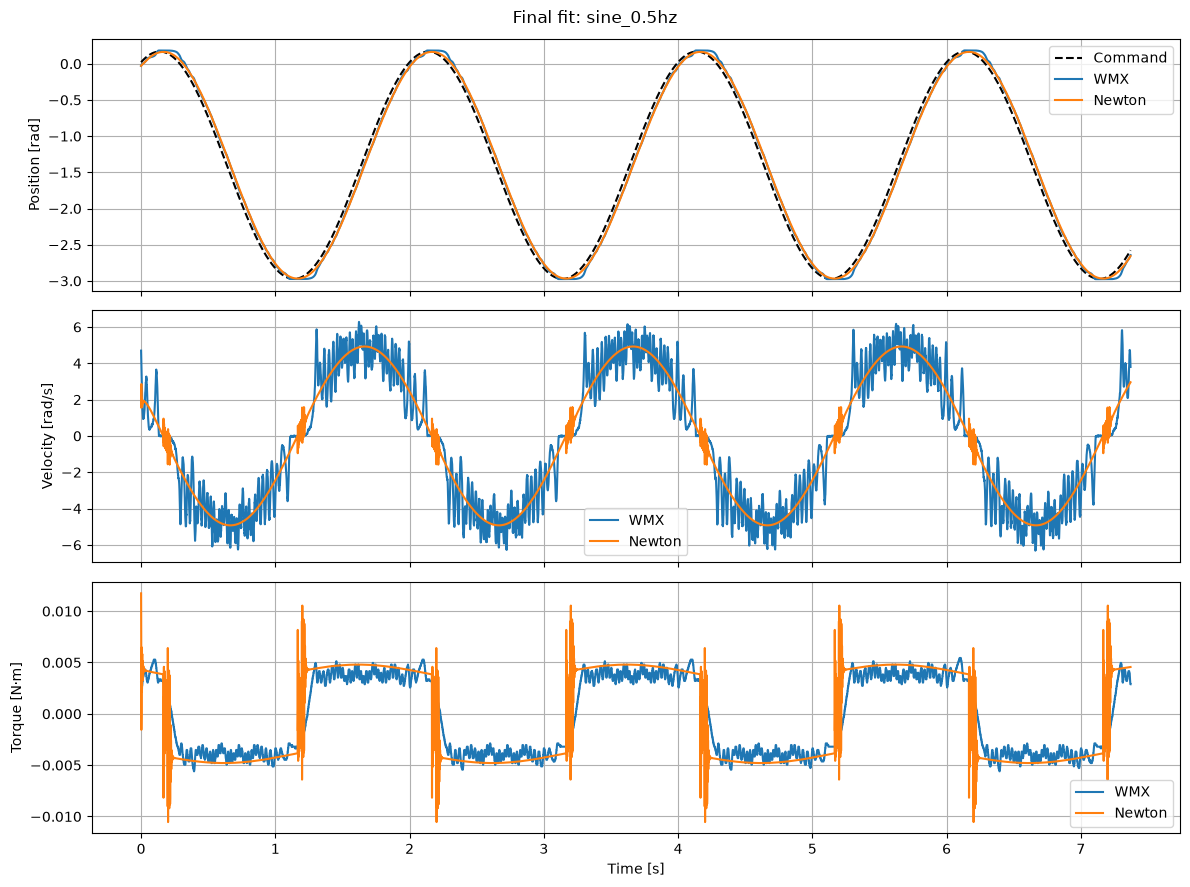

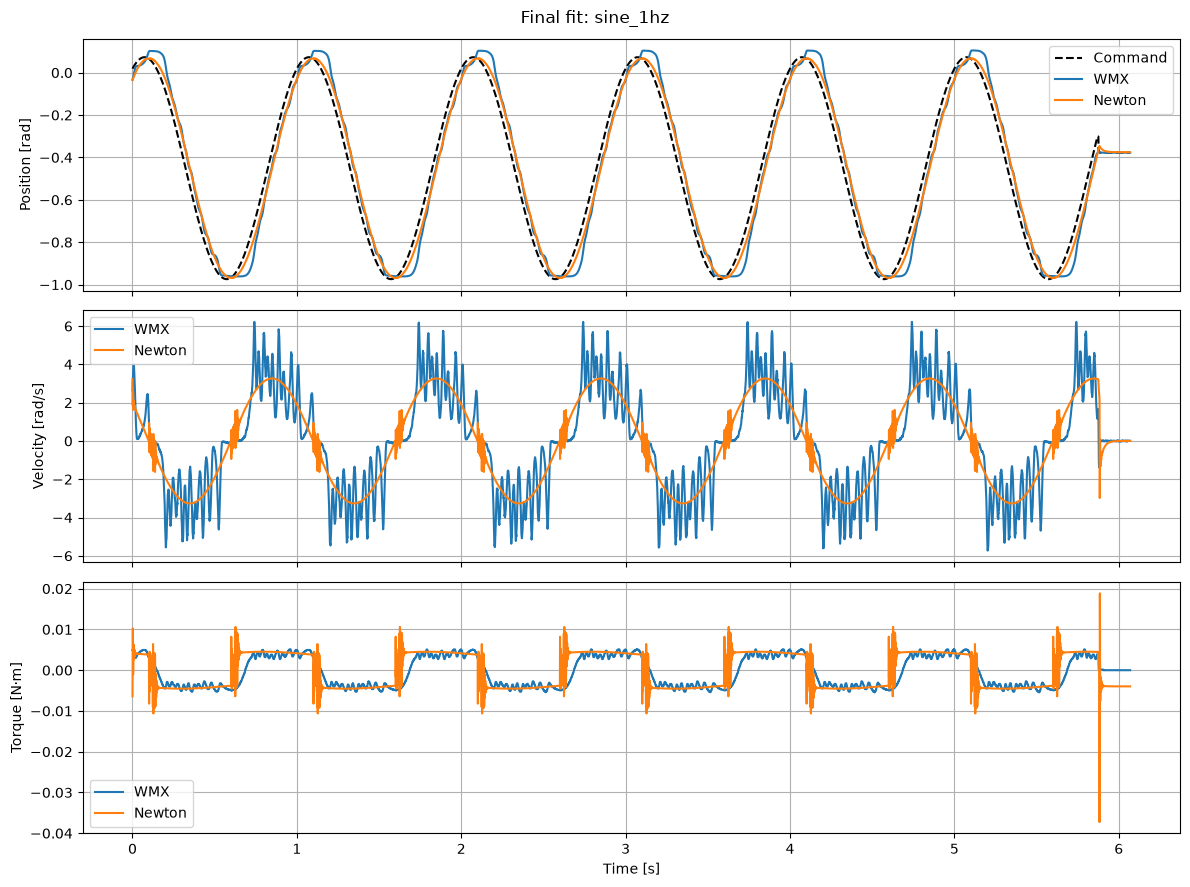

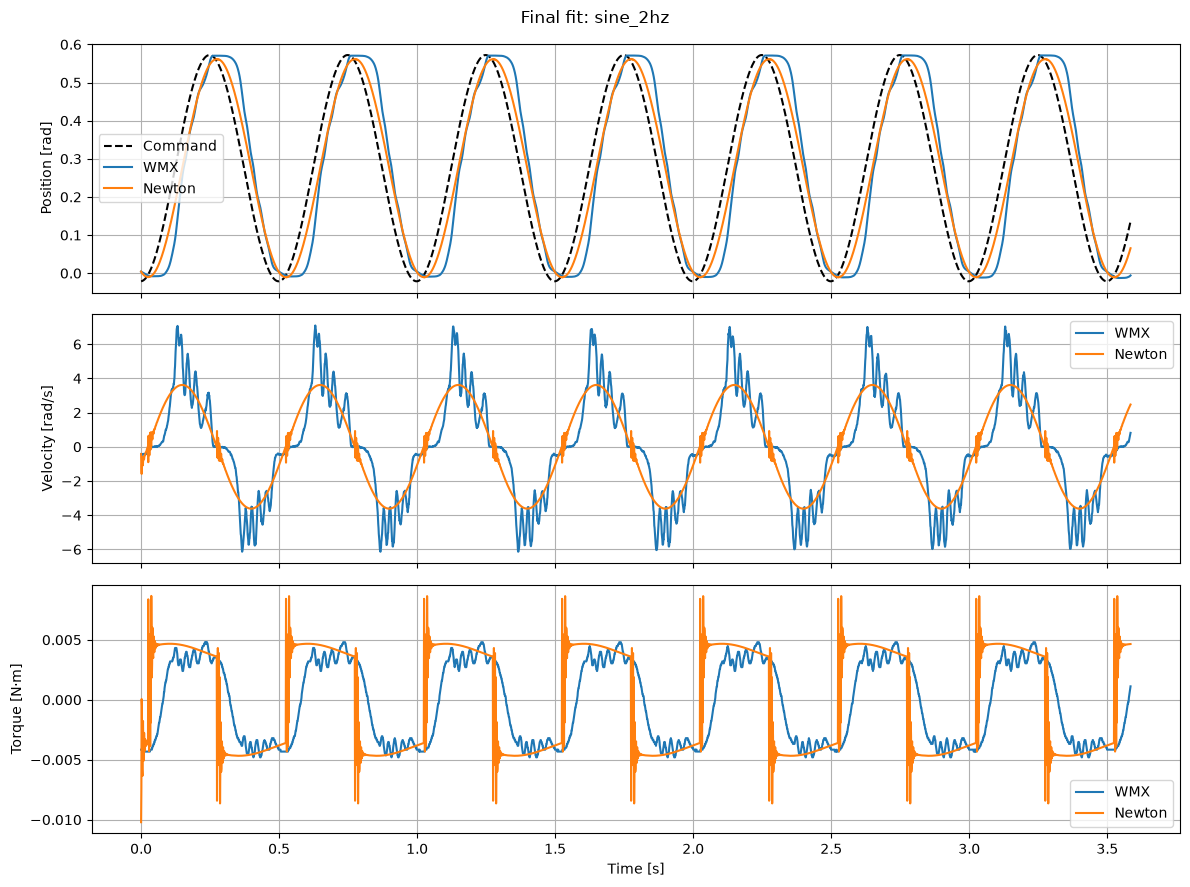

In [9]:
pre_refinement_params = current_params

# 서로 떨어진 구간은 각각 독립 시뮬레이션하며 모든 구간의 dt는 원본 1 ms이다.
refinement_windows = [*step_fit_windows, *ramp_fit_windows, *multi_sine_windows, datasets["stop"]]
if any(not np.isclose(data["dt"], data["source_dt"]) for data in refinement_windows):
    raise RuntimeError("Refinement 입력의 dt가 원본 로그와 다릅니다.")

REFINEMENT_WEIGHTS = {"position": 1.0, "velocity": 0.8, "torque": 0.8}
refinement_budget = 140
delay_polish_budget = 24

refinement_fit = fit_local_refinement(
    refinement_windows, current_params, bounds_around(current_params),
    REFINEMENT_WEIGHTS, "전체 Newton 응답 미세조정",
    budget=refinement_budget, maxiter=35,
)
coarse_candidate = refinement_fit.params

delay_rechecked_params, _, delay_recheck = sweep_delay_steps(
    [step_window], coarse_candidate, delay_candidates, STEP_WEIGHTS,
    title="Step delay 재확인",
)
delay_before = int(coarse_candidate.delay_steps)
delay_after = int(delay_rechecked_params.delay_steps)
delay_changed = delay_after != delay_before
print(
    "delay 재확인:",
    {
        "before": delay_before,
        "after": delay_after,
        "step_loss": delay_recheck["losses"]["total"],
        "changed": delay_changed,
    },
)

if delay_changed:
    delay_polish_fit = fit_local_refinement(
        refinement_windows, delay_rechecked_params, bounds_around(delay_rechecked_params),
        REFINEMENT_WEIGHTS, "Delay 갱신 후 짧은 미세조정",
        budget=delay_polish_budget, maxiter=10,
    )
    coarse_candidate = delay_polish_fit.params
else:
    coarse_candidate = delay_rechecked_params

baseline_full = evaluate_params(
    fit_datasets, pre_refinement_params, REFINEMENT_WEIGHTS,
    progress_title="원본 1 ms refinement 이전 응답",
)
candidate_full = evaluate_params(
    fit_datasets, coarse_candidate, REFINEMENT_WEIGHTS,
    progress_title="원본 1 ms refinement 후보 응답",
)
if candidate_full["losses"]["total"] < baseline_full["losses"]["total"]:
    current_params = coarse_candidate
    final_fit_evaluation = candidate_full
else:
    warnings.warn("원본 1 ms 응답이 악화되어 refinement 이전 값으로 되돌립니다.")
    current_params = pre_refinement_params
    final_fit_evaluation = baseline_full

print_evaluation("최종 fitting", current_params, final_fit_evaluation, fit_datasets)
for data, simulation in zip(fit_datasets, final_fit_evaluation["simulations"]):
    plot_comparison(data, simulation, f"Final fit: {data['profile']}")


## 8. 두 S-curve 검증




S-curve validation
params = {'kp': 1.7834420458981466, 'ki': 0.0, 'kd': 0.03489275095941144, 'integral_max': 5.0, 'continuous_torque_limit': 0.16, 'peak_torque_limit': 0.48, 'thermal_time_constant': 10.0, 'inertia': 8.092287352071479e-06, 'viscous': 0.00016529462201840913, 'coulomb': 0.0039704990270451514, 'delay_steps': 6, 'torque_response_time_constant': 0.0024624683815092636}
mean loss = {'position': 0.06557532023879639, 'velocity': 1.6363381563109956, 'torque': 0.17008862073799458, 'total': 0.5541975267387873}
  scurve_validation_1: {'position': 0.07646970055720005, 'velocity': 1.9071867258070019, 'torque': 0.19290465833528433, 'total': 0.6443890289403336}
  scurve_validation_2: {'position': 0.054680939920392725, 'velocity': 1.3654895868149892, 'torque': 0.14727258314070485, 'total': 0.4640060245372411}


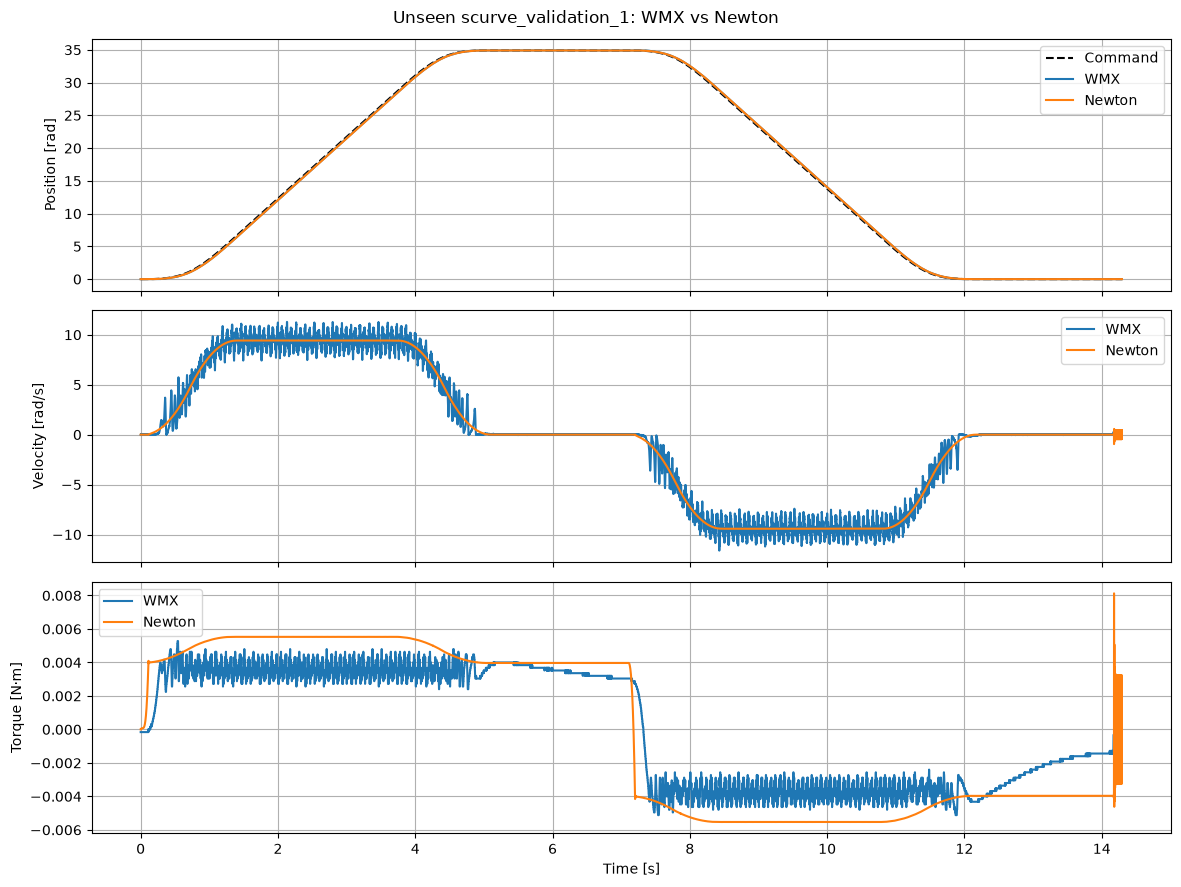

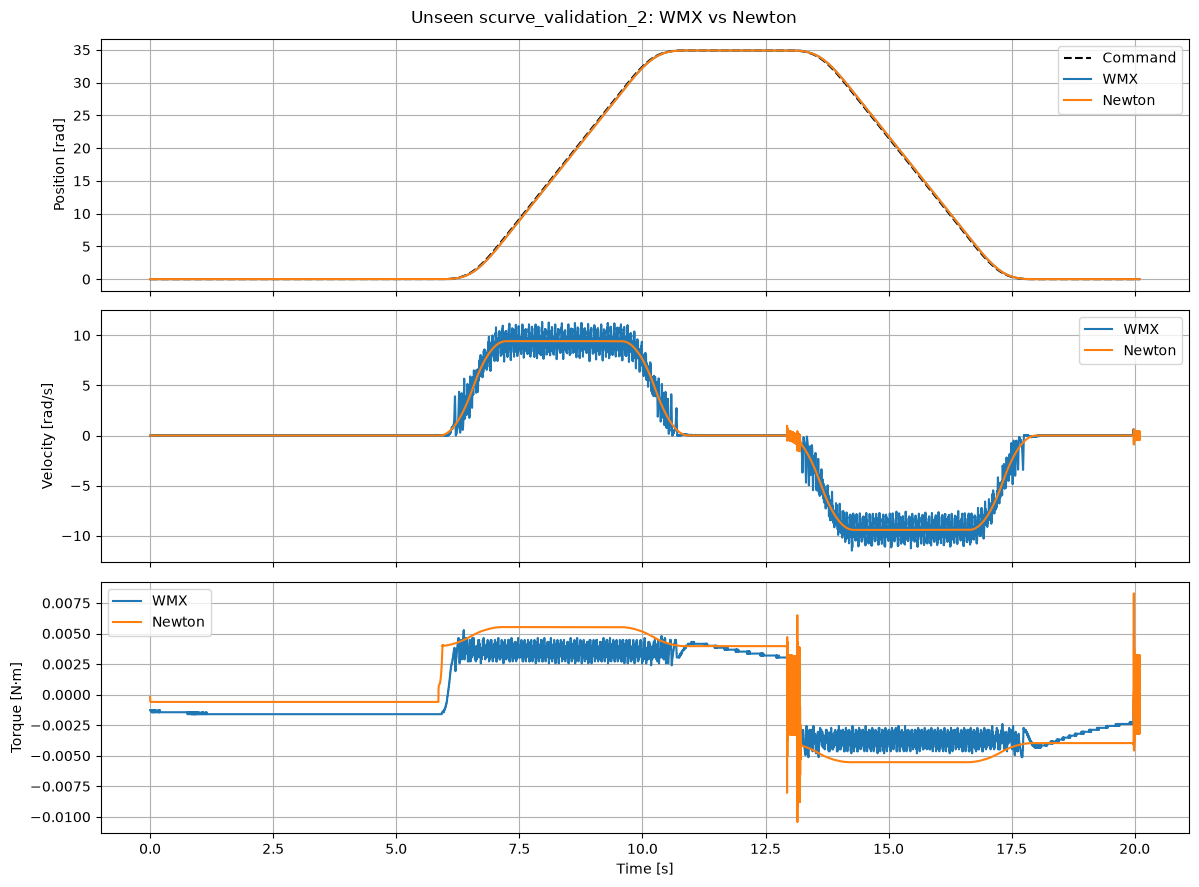

In [10]:
validation_evaluation = evaluate_params(
    validation_datasets, current_params, DEFAULT_WEIGHTS,
    progress_title="미사용 S-curve 2개 validation",
)
print_evaluation(
    "S-curve validation", current_params,
    validation_evaluation, validation_datasets,
)
for data, simulation in zip(
    validation_datasets, validation_evaluation["simulations"]
):
    plot_comparison(
        data, simulation,
        f"Unseen {data['profile']}: WMX vs Newton",
    )

## 9. 결과 저장



In [11]:
RESULT_PATH = PROJECT_ROOT / "fitted_motor_params.json"
result_payload = {
    "motor_params": asdict(current_params),
    "fit_logs": {name: datasets[name]["source"] for name in fit_dataset_names},
    "validation_logs": {
        name: datasets[name]["source"] for name in validation_dataset_names
    },
    "fit_losses": final_fit_evaluation["losses"],
    "validation_losses": validation_evaluation["losses"],
}
RESULT_PATH.write_text(json.dumps(result_payload, indent=2), encoding="utf-8")
print("저장 완료:", RESULT_PATH.resolve())


저장 완료: /home/ireh21/rei/fitted_motor_params.json


## 10. 검증 및 확인

In [10]:
import sys
from pathlib import Path

project_root = globals().get("PROJECT_ROOT")
if project_root is None:
    project_root = next(
        (path for path in (Path.cwd(), *Path.cwd().parents)
         if (path / "code" / "single_motor_twin.py").exists()),
        None,
    )
if project_root is None:
    raise FileNotFoundError("code/single_motor_twin.py를 찾을 수 없습니다.")
if str(project_root / "code") not in sys.path:
    sys.path.insert(0, str(project_root / "code"))

from result_summary import print_summary, summarize_result_bundle

result_json = Path(globals().get("RESULT_PATH", project_root / "fitted_motor_params.json"))
summary = summarize_result_bundle(result_json, mode="04_1")
print_summary(summary)


Module validate_and_correct_inertia_kernel_5e18b3cd 2f0edb1 load on device 'cpu' took 9.72 ms  (cached)
Module newton._src.geometry.bvh 24ddd6d load on device 'cpu' took 1.85 ms  (cached)
Module newton._src.sim.articulation 57145c7 load on device 'cpu' took 2.53 ms  (cached)
Module newton._src.solvers.featherstone.kernels 4399e75 load on device 'cpu' took 2.76 ms  (cached)
VALIDATION
  position_nrmse: 0.000906647
  velocity_nrmse: 0.105966
  torque_nrmse: 0.495238

STEP
  rise_error_s: 0.00875
  settling_error_s: 0.02625
  overshoot_error: 0.00469696

RAMP
  torque_bias_abs: 0.000116167

SINE
  gain_abs_error: 0.0358239
  phase_abs_error_deg: 1.94667


보통 약 290분 정도 소요,  

